In [1]:
import numpy as np
import pandas as pd
from pandas import MultiIndex, Int16Dtype
import time
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import json

from datetime import datetime
import xgboost as xgb
import shap

from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.metrics import log_loss, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, accuracy_score, balanced_accuracy_score, f1_score, make_scorer, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.tree import DecisionTreeClassifier

from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import NonParamDML, LinearDML, SparseLinearDML, CausalForestDML, DML, KernelDML
from econml.dml._rlearner import _RLearner
from econml.dr import DRLearner
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
from econml.score import EnsembleCateEstimator

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from econml.sklearn_extensions.model_selection import GridSearchCVList
from sklearn.base import clone

from scipy.stats import ttest_ind, t

import lightgbm as lgbm

from functools import partialmethod

import itertools

%matplotlib inline

In [2]:
colors= ['#FFED00', '#001631', '#2F6C7A', '#7CA5AE', '#D2E1E5', '#BF0643']
sns.set_palette(colors)

# Data Import

In [3]:
import pandas as pd
import numpy as np
 
def _norm_id_to_str(s: pd.Series) -> pd.Series:
    """
    Normalisiert IDs robust zu String:
    - entfernt .0 aus Float-Strings
    - trimmt Whitespaces
    - setzt <NA> sauber
    """
    # erst zu pandas StringDtype
    s = s.astype("string")
 
    # häufig: "123.0" -> "123"
    s = s.str.replace(r"\.0$", "", regex=True)
 
    # trim
    s = s.str.strip()
 
    return s
 
def lade_und_bereite_daten_vor_ebox_post(
    pfad_df_ebox,
    pfad_df_post,
    pfad_kuendigungen,
    pfad_profit_parquet,
    key_df_profit='DWH_VERTRAGSAKTE_ID',
    key_profit='ve_id_dwh',
    key_df_kuendigungen='DWH_VERTRAGSAKTE_ID',
    key_kuendigungen='VERTRAGSAKTE_ID',
    col_group='GRUPPE',
    col_sorttag='SORTIERUNG_INDEX_TAG',
    profit_col='ve_profit',
    profit_agg='mean',
):
    df_ebox = pd.read_csv(
        pfad_df_ebox, delimiter=';', low_memory=False, encoding='latin-1',
        na_values=['-inf', 'inf', 'NA', 'NaN', 'Infinity']
    )
    df_post = pd.read_csv(
        pfad_df_post, delimiter=';', low_memory=False, encoding='latin-1',
        na_values=['-inf', 'inf', 'NA', 'NaN', 'Infinity']
    )
 
    df_ebox['EBOX_J_BLK'] = 'E'
    df_post['EBOX_J_BLK'] = 'P'
 
    df_ebox['QUELLE_VERSAND'] = 'EBOX'
    df_post['QUELLE_VERSAND'] = 'POST'
 
    df = pd.concat([df_ebox, df_post], ignore_index=True, sort=False)
 
    kündig = pd.read_csv(
        pfad_kuendigungen, delimiter=';', low_memory=False, encoding='latin-1',
        na_values=['-inf', 'inf', 'NA', 'NaN', 'Infinity']
    )
    kündig['KÜNDIGUNG'] = 1
    kündig = kündig.drop(columns=[c for c in ['DWH_PARTNER_ID'] if c in kündig.columns])
 
    prof = pd.read_parquet(pfad_profit_parquet)
 
    missing = [c for c in [key_profit, profit_col] if c not in prof.columns]
    if missing:
        raise KeyError(f"Profit-Parquet fehlt Spalten: {missing}. Verfügbar: {list(prof.columns)[:50]} ...")
 
    # --- KEY TYPEN ANGLEICHEN (Fix für deinen Fehler)
    df[key_df_profit] = _norm_id_to_str(df[key_df_profit])
    prof[key_profit] = _norm_id_to_str(prof[key_profit])
    kündig[key_kuendigungen] = _norm_id_to_str(kündig[key_kuendigungen])
    df[key_df_kuendigungen] = _norm_id_to_str(df[key_df_kuendigungen])
 
    # Profit duplikate behandeln
    if profit_agg is not None:
        if profit_agg not in ('sum', 'max', 'mean'):
            raise ValueError("profit_agg muss 'sum', 'max', 'mean' oder None sein.")
        agg_fun = {'sum': 'sum', 'max': 'max', 'mean': 'mean'}[profit_agg]
        prof = prof.groupby(key_profit, as_index=False)[profit_col].agg(agg_fun)
 
    # --- Merges
    df = df.merge(prof[[key_profit, profit_col]], how='left', left_on=key_df_profit, right_on=key_profit)
    df = df.merge(kündig, how='left', left_on=key_df_kuendigungen, right_on=key_kuendigungen)
 
    # NaNs behandeln
    df['KÜNDIGUNG'] = df['KÜNDIGUNG'].fillna(0).astype(int)
    df[profit_col] = df[profit_col].fillna(0)
 
    # Abgeleitete Spalten
    if col_group in df.columns:
        df['GRUPPE_ZU'] = np.where(df[col_group] == 'Optimierung', 'Optimierung', 'Random')
    else:
        df['GRUPPE_ZU'] = 'unbekannt'
 
    df['KÜNDIGUNG_MAL_PROFIT'] = df['KÜNDIGUNG'] * df[profit_col]
 
    if col_sorttag in df.columns:
        df['WOCHE'] = ((df[col_sorttag] - 1) // 5 + 1)
        df['ZEITRAUM'] = (df[col_sorttag] / 12.1).astype(int)
 
    if col_group in df.columns and 'EBOX_J_BLK' in df.columns:
        df.loc[(df[col_group] == 'Optimierung') & (df['EBOX_J_BLK'] == 'E'), col_group] = 'Optimierung Ebox'
        df.loc[(df[col_group] == 'Optimierung') & (df['EBOX_J_BLK'] == 'P'), col_group] = 'Optimierung Post'
 
    return df

In [184]:
df = lade_und_bereite_daten_vor_ebox_post(
    pfad_df_ebox='/domino/edv/pvc-hf1kundehuk/Rechnungsversand/Evaluation_2526/DAT_FUER_DA_EBOX_2025_KORR.csv',
    pfad_df_post='/domino/edv/pvc-hf1kundehuk/Rechnungsversand/Evaluation_2526/DAT_FUER_DA_ZUR_TEST_2025.csv',
    pfad_kuendigungen='/domino/edv/pvc-hf1kundehuk/Rechnungsversand/Evaluation_2526/DAT_ABGANG_JW_STAND_25012026.csv',
    pfad_profit_parquet='/domino/edv/pvc-hf1kundehuk/Rechnungsversand/Kundenwert/vertragswerte_pkw_28082025.parquet',
    key_df_profit="DWH_VERTRAGSAKTE_ID",
    key_profit="ve_id_dwh",
)

In [185]:
df

,DWH_PARTNER_ID,vnr,DWH_VERTRAGSAKTE_ID,SORTIERUNG_INDEX_TAG,GRUPPE,EBOX_J_BLK,QUELLE_VERSAND,ve_id_dwh,ve_profit,VERTRAGSAKTE_ID,ANZ_ECHTER_ABGANG,KÜNDIGUNG,GRUPPE_ZU,KÜNDIGUNG_MAL_PROFIT,WOCHE,ZEITRAUM
0,44463898,636300123,196809237,3,Random Ebox,E,EBOX,196809237,36.160914,<NA>,NaN,0,Random,0.000000,1,0
1,48462909,608272367,165326665,3,Random Ebox,E,EBOX,165326665,28.538058,<NA>,NaN,0,Random,0.000000,1,0
2,82909373,618196535,179271247,3,Random Ebox,E,EBOX,179271247,-23.419425,179271247,1.0,1,Random,-23.419425,1,0
3,83499022,639236459,1340303880,3,Random Ebox,E,EBOX,1340303880,105.370135,<NA>,NaN,0,Random,0.000000,1,0
4,83499022,610371411,168642298,3,Random Ebox,E,EBOX,168642298,155.344309,<NA>,NaN,0,Random,0.000000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4781690,2457857137,623141945,1577271470,5,Optimierung Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Optimierung,0.000000,1,0
4781691,436718502,635919802,1577273759,5,Optimierung Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Optimierung,0.000000,1,0
4781692,2457830044,646496004,1577274920,4,Optimierung Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Optimierung,0.000000,1,0
4781693,2457851256,652489809,1577275500,5,Optimierung Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Optimierung,0.000000,1,0


In [186]:
df.GRUPPE.value_counts()

GRUPPE
Optimierung Post    2983163
Optimierung Ebox     843032
Random Post          744877
Random Ebox          210623
Name: count, dtype: int64

In [187]:
df.KÜNDIGUNG.sum()

129282

In [188]:
df.ve_profit.value_counts()

ve_profit
 0.000000      340216
 0.294117          43
 0.521008           6
 250.402480         6
 209.954672         5
                ...  
-269.884496         1
-8.251185           1
 87.574292          1
 38.381406          1
 78.846393          1
Name: count, Length: 4441143, dtype: int64

In [189]:
df[df['GRUPPE'] == 'Random Post'].SORTIERUNG_INDEX_TAG.value_counts()

SORTIERUNG_INDEX_TAG
24    20840
28    20811
1     20783
32    20768
6     20767
5     20763
14    20759
7     20755
3     20753
19    20749
35    20748
20    20735
21    20727
30    20722
31    20719
29    20715
15    20708
16    20700
11    20682
33    20681
27    20679
26    20673
9     20666
34    20663
12    20662
23    20662
18    20657
10    20647
22    20638
25    20635
13    20627
8     20598
17    20583
4     20582
2     20581
36    20439
Name: count, dtype: int64

In [190]:
df[df['GRUPPE'] == 'Random Ebox'].SORTIERUNG_INDEX_TAG.value_counts()

SORTIERUNG_INDEX_TAG
3     25273
24    16782
19    15835
9     13082
14    10471
22     8932
29     8537
6      8448
25     8418
13     8416
10     8415
4      8413
11     8399
28     8398
26     8392
5      8348
23     8337
16     7993
18     7949
15     7851
8      3934
Name: count, dtype: int64

In [191]:
def rebalance_subset_by_feature(
    df: pd.DataFrame,
    subset_df: pd.DataFrame,
    feature_col: str,
    reference_value,
    target_n: int | None = None,
    replace_upsample: bool = True,
    keep_reference: bool = True,
    random_state: int | None = None,
    shuffle_result: bool = True,
) -> pd.DataFrame:
    """
    Rebalanciert eine Teilmenge eines DataFrames entlang einer Feature-Ausprägung und ersetzt
    anschließend diese Teilmenge im Gesamtdatensatz durch die rebalancierte Version.
 
    Wird target_n nicht explizit angegeben, wird die Häufigkeit der Referenz-Ausprägung innerhalb
    der Teilmenge als Zielhäufigkeit verwendet.
 
    Parameter
    ----------
    df : pd.DataFrame
        Gesamter Eingabedatensatz.
    subset_df : pd.DataFrame
        Teilmenge des DataFrames, die rebalanciert werden soll
        (z. B. df[df["GRUPPE"] == "Random Ebox"]).
    feature_col : str
        Name der Feature-Spalte, entlang der innerhalb der Teilmenge rebalanciert werden soll.
    reference_value :
        Referenz-Ausprägung des Features.
    target_n : int oder None, optional
        Gewünschte Anzahl an Beobachtungen pro Feature-Ausprägung.
        Falls None, wird automatisch die Häufigkeit der Referenz-Ausprägung verwendet.
    replace_upsample : bool, optional (default=True)
        Gibt an, ob beim Upsampling mit Zurücklegen gesampelt werden darf.
    keep_reference : bool, optional (default=True)
        Gibt an, ob die Referenz-Ausprägung unverändert beibehalten werden soll.
    random_state : int oder None, optional
        Zufallsseed zur Reproduzierbarkeit des Samplings.
    shuffle_result : bool, optional (default=True)
        Gibt an, ob die rebalancierte Teilmenge am Ende gemischt werden soll.
 
    Rückgabewert
    ------------
    pd.DataFrame
        Gesamtdatensatz mit ersetzter, rebalancierter Teilmenge.
    """
 
    if not subset_df.index.isin(df.index).all():
        raise ValueError("subset_df muss ein echtes Subset von df sein (Index muss enthalten sein).")
 
    if feature_col not in df.columns:
        raise ValueError(f"Spalte '{feature_col}' nicht im DataFrame vorhanden.")
 
    if subset_df.empty:
        return df.copy()
 
    if reference_value not in subset_df[feature_col].values:
        raise ValueError(
            f"Referenz-Ausprägung '{reference_value}' nicht in subset_df in Spalte '{feature_col}' gefunden."
        )
 
    # Zielhäufigkeit bestimmen
    if target_n is None:
        target_n = (subset_df[feature_col] == reference_value).sum()
 
    rebalanced_groups = []
 
    for value, group in subset_df.groupby(feature_col):
        n_current = len(group)
 
        # Referenzgruppe optional unverändert lassen
        if value == reference_value and keep_reference:
            rebalanced_groups.append(group)
            continue
 
        if n_current == target_n:
            sampled = group
        elif n_current > target_n:
            sampled = group.sample(
                n=target_n, replace=False, random_state=random_state
            )
        else:
            sampled = group.sample(
                n=target_n, replace=replace_upsample, random_state=random_state
            )
 
        rebalanced_groups.append(sampled)
 
    subset_rebalanced = pd.concat(rebalanced_groups, axis=0)
 
    if shuffle_result:
        subset_rebalanced = subset_rebalanced.sample(
            frac=1, random_state=random_state
        )
 
    subset_rebalanced = subset_rebalanced.reset_index(drop=True)
 
    # Ursprüngliche Teilmenge entfernen und ersetzen
    df_rest = df.drop(index=subset_df.index)
 
    df_out = (
        pd.concat([df_rest, subset_rebalanced], axis=0)
        .reset_index(drop=True)
    )
 
    return df_out

In [192]:
subset = df[df["GRUPPE"] == "Random Ebox"]
 
df = rebalance_subset_by_feature(
    df=df,
    subset_df=subset,
    feature_col="SORTIERUNG_INDEX_TAG",
    reference_value=15,
    #target_n=10_000,
    random_state=0,
)

In [193]:
df[df['GRUPPE'] == 'Random Ebox'].SORTIERUNG_INDEX_TAG.value_counts()

SORTIERUNG_INDEX_TAG
29    7851
8     7851
23    7851
3     7851
19    7851
14    7851
10    7851
22    7851
11    7851
26    7851
25    7851
15    7851
6     7851
9     7851
18    7851
5     7851
24    7851
13    7851
16    7851
28    7851
4     7851
Name: count, dtype: int64

In [194]:
df

,DWH_PARTNER_ID,vnr,DWH_VERTRAGSAKTE_ID,SORTIERUNG_INDEX_TAG,GRUPPE,EBOX_J_BLK,QUELLE_VERSAND,ve_id_dwh,ve_profit,VERTRAGSAKTE_ID,ANZ_ECHTER_ABGANG,KÜNDIGUNG,GRUPPE_ZU,KÜNDIGUNG_MAL_PROFIT,WOCHE,ZEITRAUM
0,85004050,504211480,116879446,3,Optimierung Ebox,E,EBOX,116879446,-154.069788,<NA>,NaN,0,Optimierung,-0.0,1,0
1,2053801671,529737589,1258001451,3,Optimierung Ebox,E,EBOX,1258001451,-284.914358,<NA>,NaN,0,Optimierung,-0.0,1,0
2,87007906,636222519,196602255,3,Optimierung Ebox,E,EBOX,196602255,-153.704940,<NA>,NaN,0,Optimierung,-0.0,1,0
3,85218981,501411560,113407458,3,Optimierung Ebox,E,EBOX,113407458,-76.221385,<NA>,NaN,0,Optimierung,-0.0,1,0
4,1654476385,637871124,805405402,3,Optimierung Ebox,E,EBOX,805405402,-154.484348,<NA>,NaN,0,Optimierung,-0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4735938,82419770,652156760,1299880394,18,Random Ebox,E,EBOX,1299880394,-171.010707,<NA>,NaN,0,Random,-0.0,4,1
4735939,82742377,616063170,176977866,18,Random Ebox,E,EBOX,176977866,-1.886482,<NA>,NaN,0,Random,-0.0,4,1
4735940,47267142,508419105,119455196,28,Random Ebox,E,EBOX,119455196,118.732248,<NA>,NaN,0,Random,0.0,6,2
4735941,49583903,604573307,1292333382,23,Random Ebox,E,EBOX,1292333382,176.214927,<NA>,NaN,0,Random,0.0,5,1


# Weighting for Versandmengen

In [195]:
def ordne_wochen(df, bins, labels, tag_spalte='SORTIERUNG_INDEX_TAG', out_col='WOCHE'):
    # sicherstellen, dass der Tag numerisch ist
    s = pd.to_numeric(df[tag_spalte], errors='coerce')
 
    # cutten
    w = pd.cut(
        s,
        bins=bins,
        right=True,
        labels=labels,
        include_lowest=True
    )
 
    # nullable int statt int (kann NA enthalten)
    df[out_col] = w.astype("Int64")
    return df

In [196]:
# Manuelle Definition der Wochenbereiche
bins = [1, 2, 7, 12, 17, 22, 27, 32, 36]  # Endpunkte der Intervalle
labels = [1, 2, 3, 4, 5, 6, 7, 8]  # Namen für die Wochen

In [197]:
df = ordne_wochen(df, bins, labels, tag_spalte='SORTIERUNG_INDEX_TAG')

In [198]:
df

,DWH_PARTNER_ID,vnr,DWH_VERTRAGSAKTE_ID,SORTIERUNG_INDEX_TAG,GRUPPE,EBOX_J_BLK,QUELLE_VERSAND,ve_id_dwh,ve_profit,VERTRAGSAKTE_ID,ANZ_ECHTER_ABGANG,KÜNDIGUNG,GRUPPE_ZU,KÜNDIGUNG_MAL_PROFIT,WOCHE,ZEITRAUM
0,85004050,504211480,116879446,3,Optimierung Ebox,E,EBOX,116879446,-154.069788,<NA>,NaN,0,Optimierung,-0.0,2,0
1,2053801671,529737589,1258001451,3,Optimierung Ebox,E,EBOX,1258001451,-284.914358,<NA>,NaN,0,Optimierung,-0.0,2,0
2,87007906,636222519,196602255,3,Optimierung Ebox,E,EBOX,196602255,-153.704940,<NA>,NaN,0,Optimierung,-0.0,2,0
3,85218981,501411560,113407458,3,Optimierung Ebox,E,EBOX,113407458,-76.221385,<NA>,NaN,0,Optimierung,-0.0,2,0
4,1654476385,637871124,805405402,3,Optimierung Ebox,E,EBOX,805405402,-154.484348,<NA>,NaN,0,Optimierung,-0.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4735938,82419770,652156760,1299880394,18,Random Ebox,E,EBOX,1299880394,-171.010707,<NA>,NaN,0,Random,-0.0,5,1
4735939,82742377,616063170,176977866,18,Random Ebox,E,EBOX,176977866,-1.886482,<NA>,NaN,0,Random,-0.0,5,1
4735940,47267142,508419105,119455196,28,Random Ebox,E,EBOX,119455196,118.732248,<NA>,NaN,0,Random,0.0,7,2
4735941,49583903,604573307,1292333382,23,Random Ebox,E,EBOX,1292333382,176.214927,<NA>,NaN,0,Random,0.0,6,1


In [199]:
# Gewichtungen für Versand, wie VK ihn 22/23 durchgeführt hat
MENGEN_GEWICHTUNG_MEHRWERT = {1: 1160000,
                       2: 1010000,
                       3: 1020000,
                       4: 1300000,
                       5: 960000,
                       6: 820000,
                       7: 390000,
                        8: 0
                      }

In [200]:
# Mengen für die spätere Policy bestimmen
anzahl = len(MENGEN_GEWICHTUNG_MEHRWERT)
gesamtmenge = sum(MENGEN_GEWICHTUNG_MEHRWERT.values()) 

# Mengenverteilung berechnen
mengenverteilung = {k: v / gesamtmenge for k, v in MENGEN_GEWICHTUNG_MEHRWERT.items()}

# Gewichtungen an randomisierte Wochen anhängen
df['MENGENVERTEILUNG_FÜR_POLICY'] = np.where(
    df['GRUPPE'] != 'Optimierung',
    df['WOCHE'].map(mengenverteilung),  # Mappe normierte Gewichtung auf randomisierte Wochen
    1  # Optionale Gleichgewichtung für optimierte Samples
)

In [201]:
mengenverteilung

{1: 0.17417417417417416,
 2: 0.15165165165165165,
 3: 0.15315315315315314,
 4: 0.19519519519519518,
 5: 0.14414414414414414,
 6: 0.12312312312312312,
 7: 0.05855855855855856,
 8: 0.0}

In [202]:
df

,DWH_PARTNER_ID,vnr,DWH_VERTRAGSAKTE_ID,SORTIERUNG_INDEX_TAG,GRUPPE,EBOX_J_BLK,QUELLE_VERSAND,ve_id_dwh,ve_profit,VERTRAGSAKTE_ID,ANZ_ECHTER_ABGANG,KÜNDIGUNG,GRUPPE_ZU,KÜNDIGUNG_MAL_PROFIT,WOCHE,ZEITRAUM,MENGENVERTEILUNG_FÜR_POLICY
0,85004050,504211480,116879446,3,Optimierung Ebox,E,EBOX,116879446,-154.069788,<NA>,NaN,0,Optimierung,-0.0,2,0,0.151652
1,2053801671,529737589,1258001451,3,Optimierung Ebox,E,EBOX,1258001451,-284.914358,<NA>,NaN,0,Optimierung,-0.0,2,0,0.151652
2,87007906,636222519,196602255,3,Optimierung Ebox,E,EBOX,196602255,-153.704940,<NA>,NaN,0,Optimierung,-0.0,2,0,0.151652
3,85218981,501411560,113407458,3,Optimierung Ebox,E,EBOX,113407458,-76.221385,<NA>,NaN,0,Optimierung,-0.0,2,0,0.151652
4,1654476385,637871124,805405402,3,Optimierung Ebox,E,EBOX,805405402,-154.484348,<NA>,NaN,0,Optimierung,-0.0,2,0,0.151652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4735938,82419770,652156760,1299880394,18,Random Ebox,E,EBOX,1299880394,-171.010707,<NA>,NaN,0,Random,-0.0,5,1,0.144144
4735939,82742377,616063170,176977866,18,Random Ebox,E,EBOX,176977866,-1.886482,<NA>,NaN,0,Random,-0.0,5,1,0.144144
4735940,47267142,508419105,119455196,28,Random Ebox,E,EBOX,119455196,118.732248,<NA>,NaN,0,Random,0.0,7,2,0.058559
4735941,49583903,604573307,1292333382,23,Random Ebox,E,EBOX,1292333382,176.214927,<NA>,NaN,0,Random,0.0,6,1,0.123123


# Analysis

## Plots 

In [203]:
def plot_kat_balken(df, x, y, hue=None, title=None, figsize=(20,10), filter_expr=None):
    """
    Plottet einen gruppierten Balkenplot für kategorische x-Achse.
    Optional: Hue + Filter
    """
    if filter_expr is not None:
        df = df.query(filter_expr)
 
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.barplot(data=df, x=x, y=y, hue=hue, ax=ax)
    
    # Achsentitel und Titel setzen mit größerer Schrift
    ax.set_title(title or f"{y} nach {x}", fontsize=18)
    ax.set_xlabel(x, fontsize=14)
    ax.set_ylabel(y, fontsize=14)
 
    # Tick-Labels lesbarer machen
    ax.tick_params(axis='x', labelsize=12, rotation=45)
    ax.tick_params(axis='y', labelsize=12)
 
    # Legende ggf. anpassen
    if hue:
        ax.legend(title=hue, fontsize=12, title_fontsize=14)
 
    plt.tight_layout()
    plt.show()

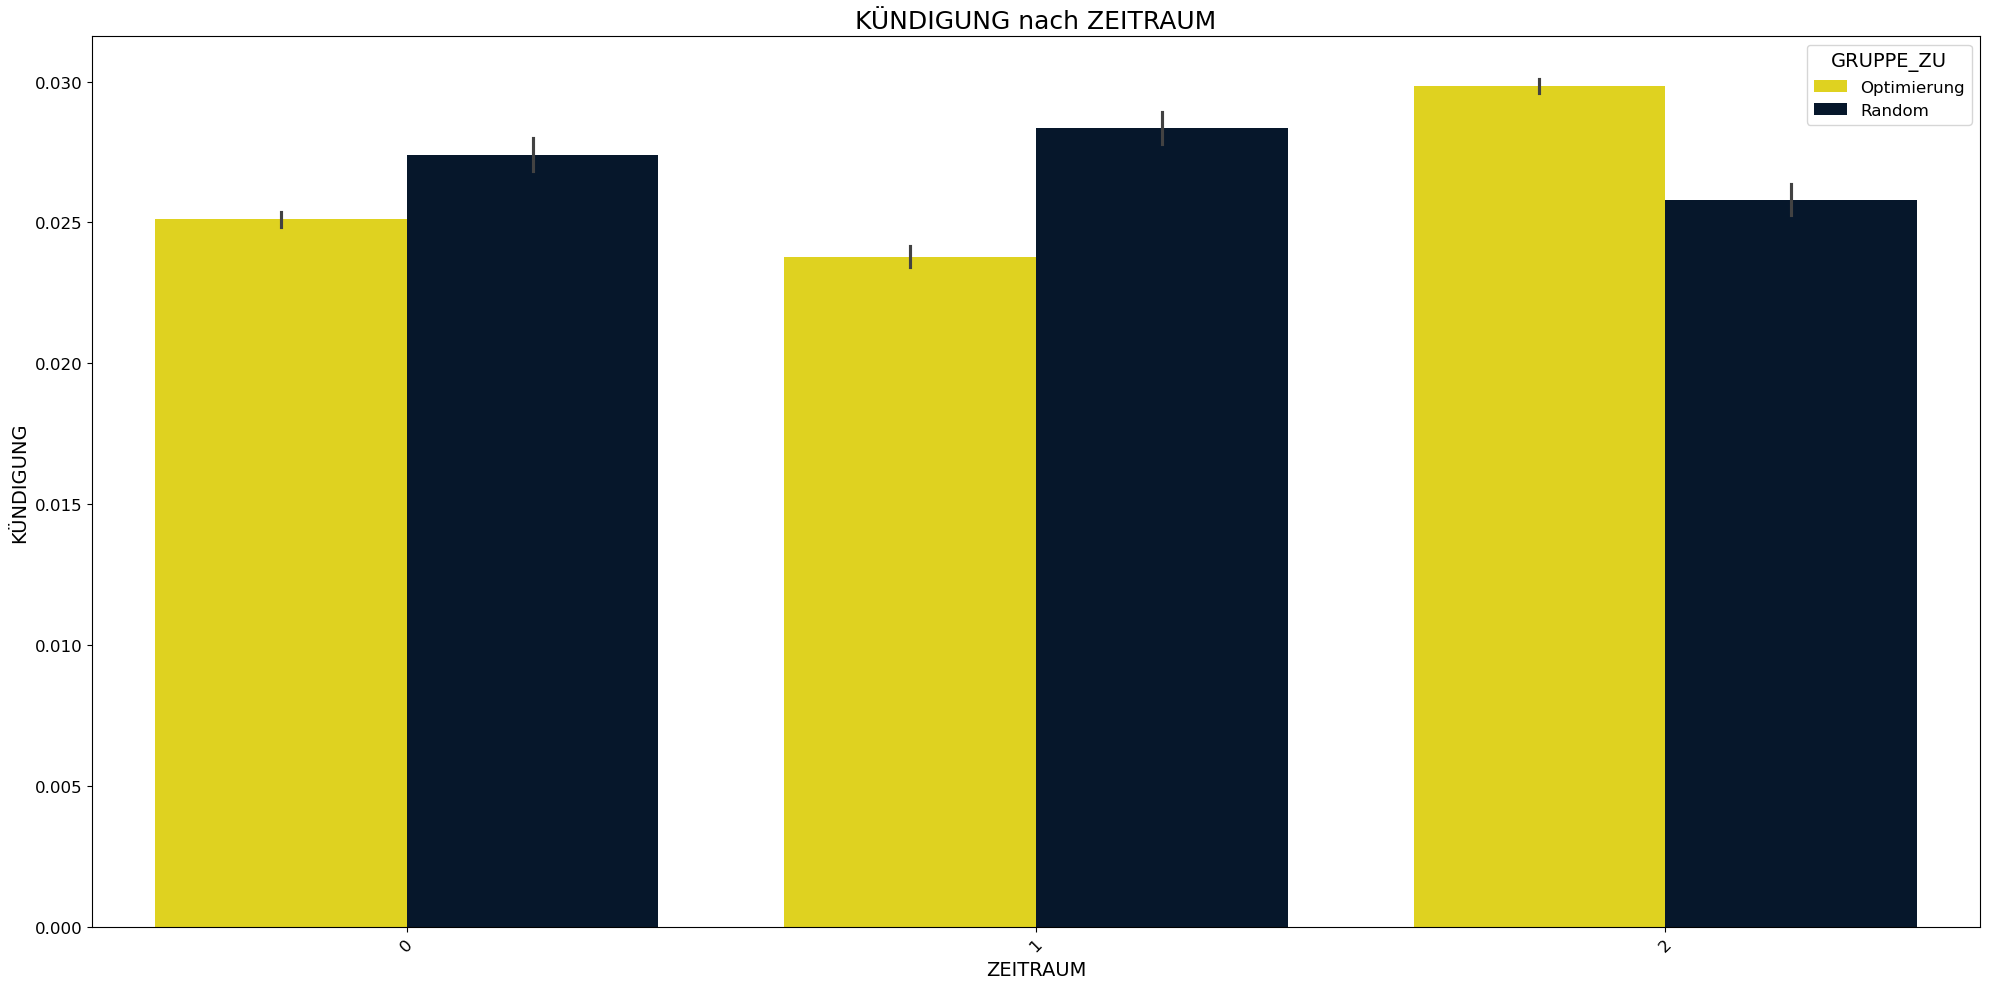

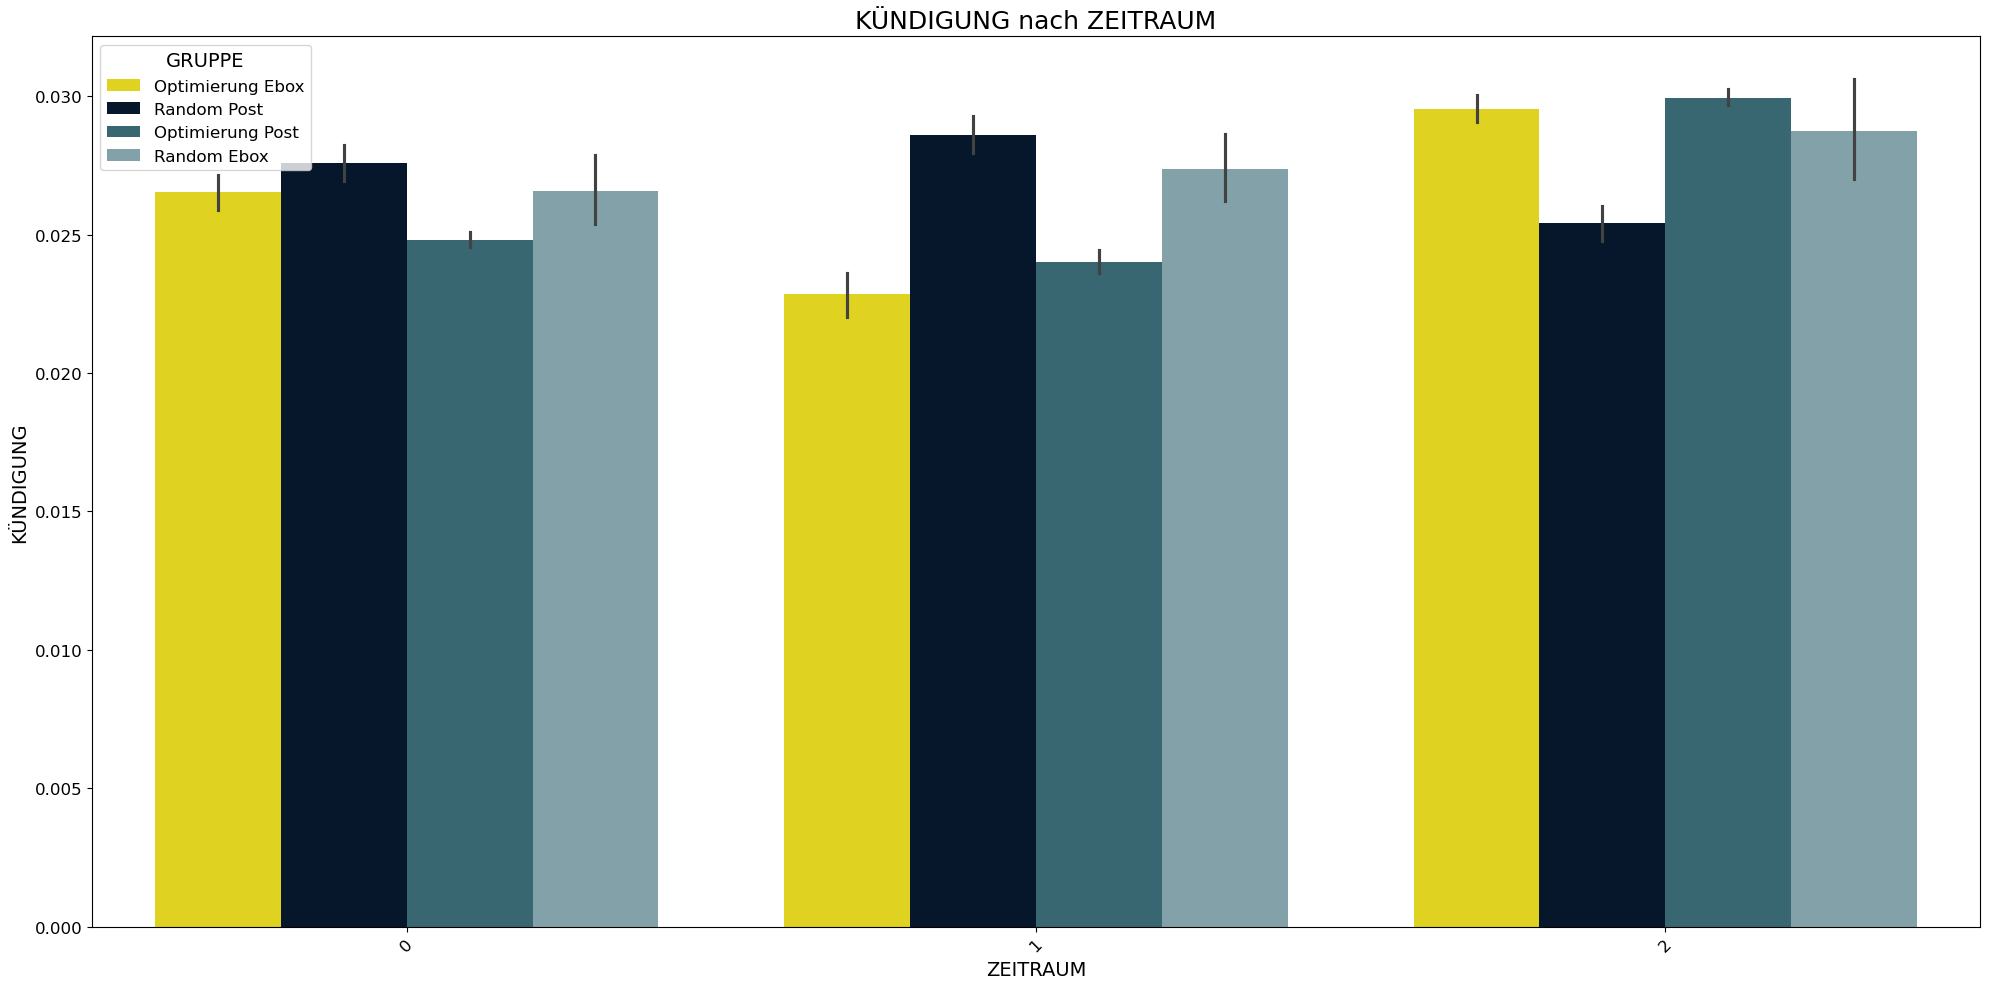

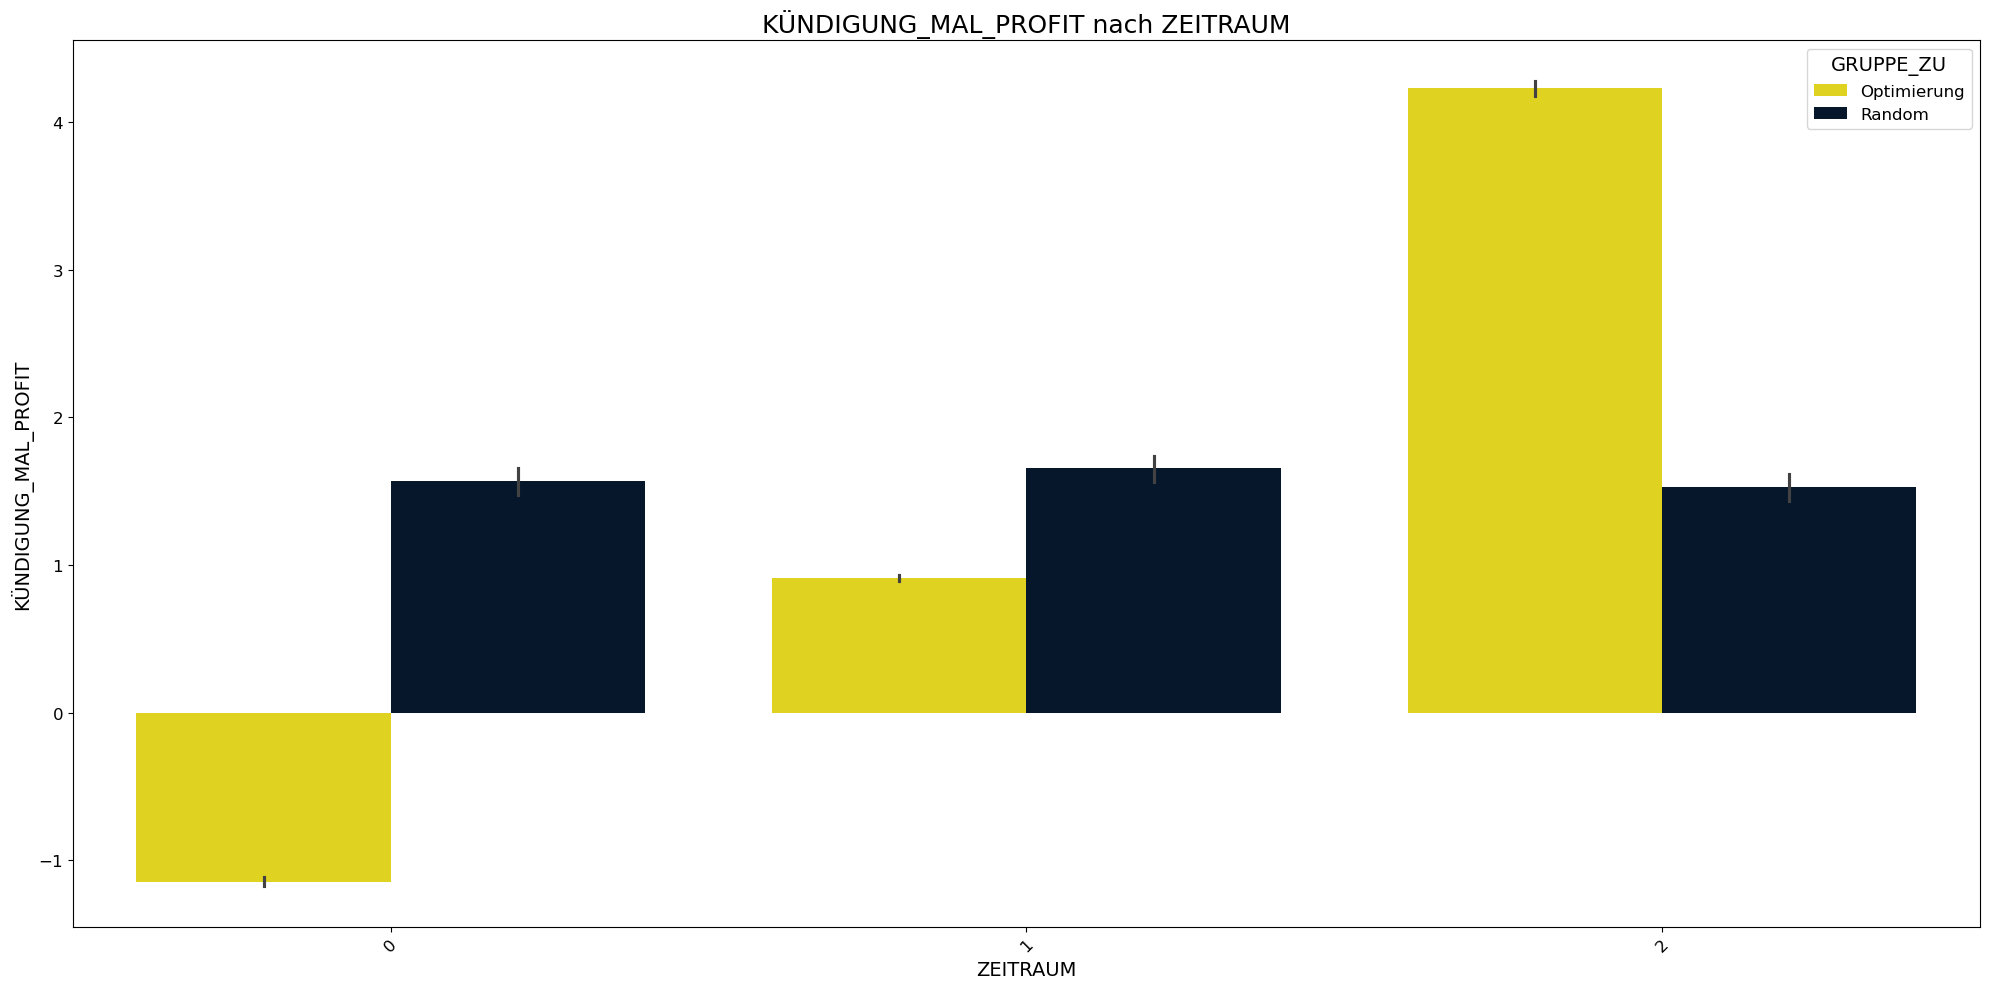

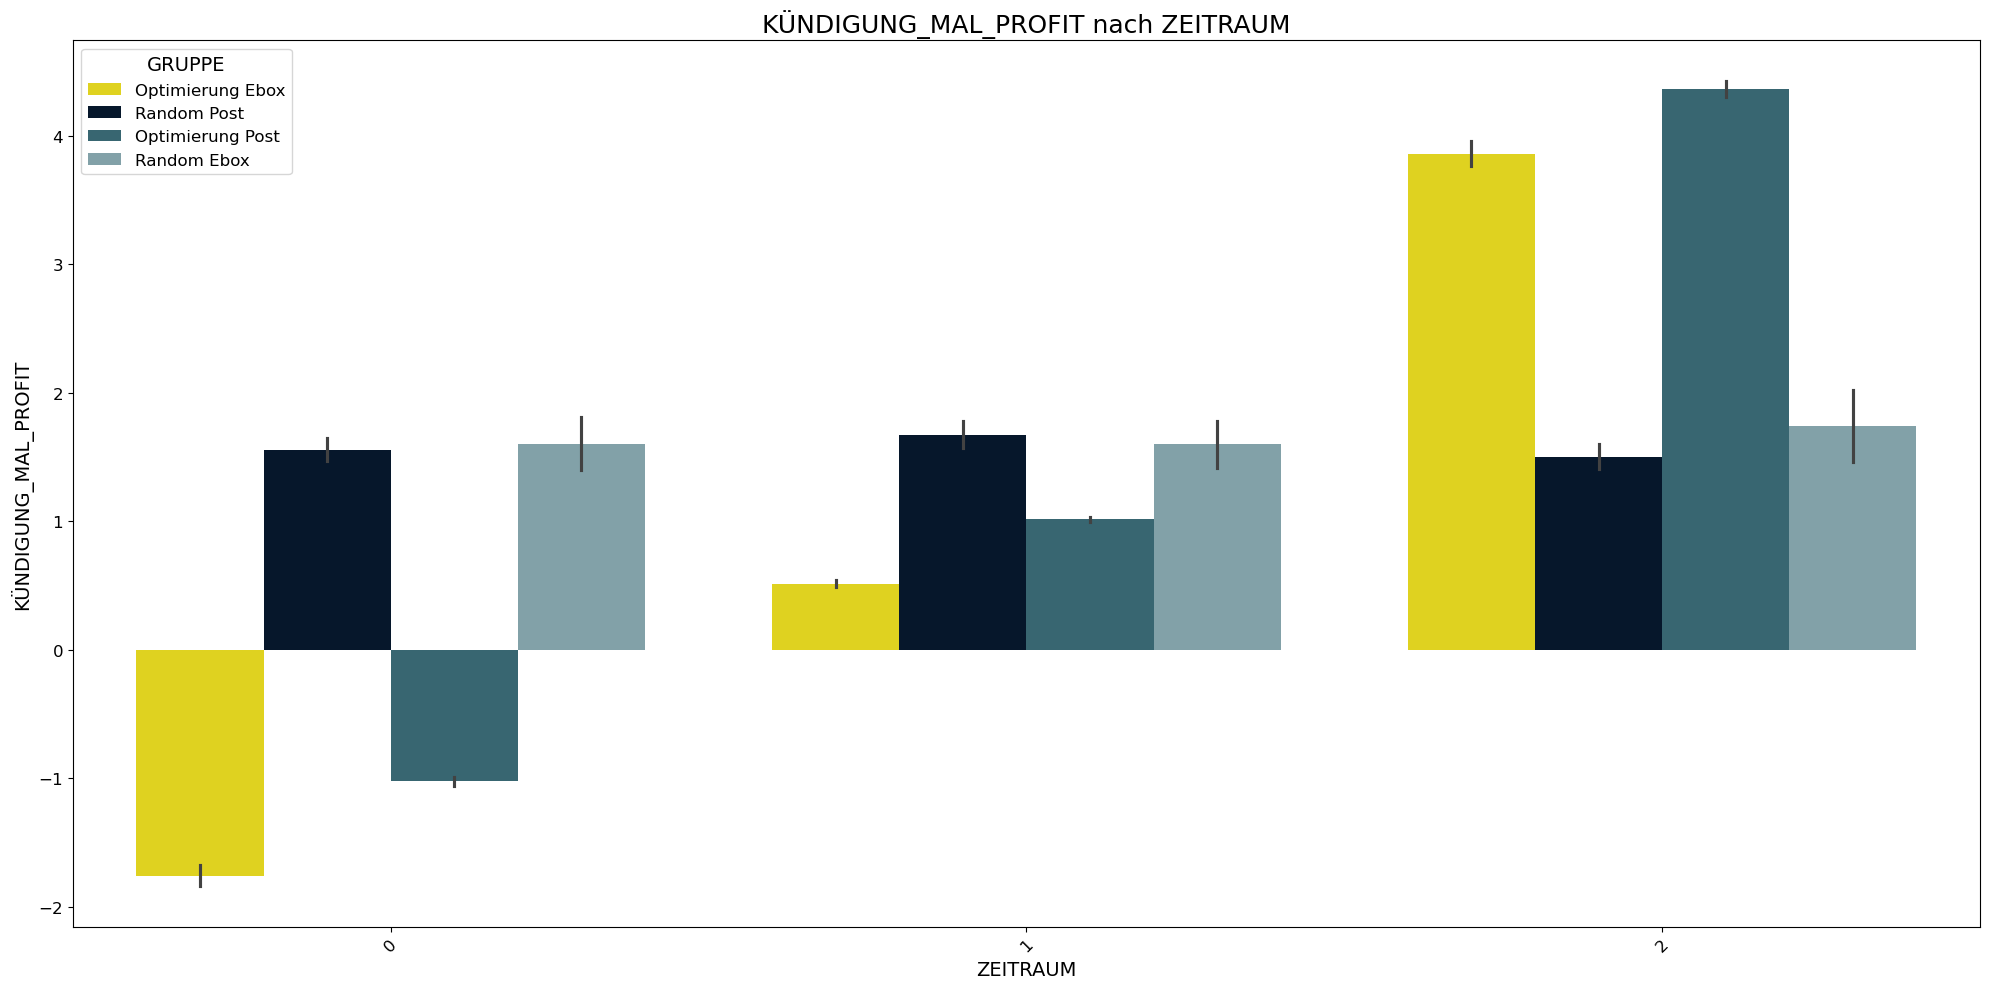

In [204]:
plot_kat_balken(df, x='ZEITRAUM', y='KÜNDIGUNG', hue='GRUPPE_ZU')
plot_kat_balken(df, x='ZEITRAUM', y='KÜNDIGUNG', hue='GRUPPE')
plot_kat_balken(df, x='ZEITRAUM', y='KÜNDIGUNG_MAL_PROFIT', hue='GRUPPE_ZU')
plot_kat_balken(df, x='ZEITRAUM', y='KÜNDIGUNG_MAL_PROFIT', hue='GRUPPE')

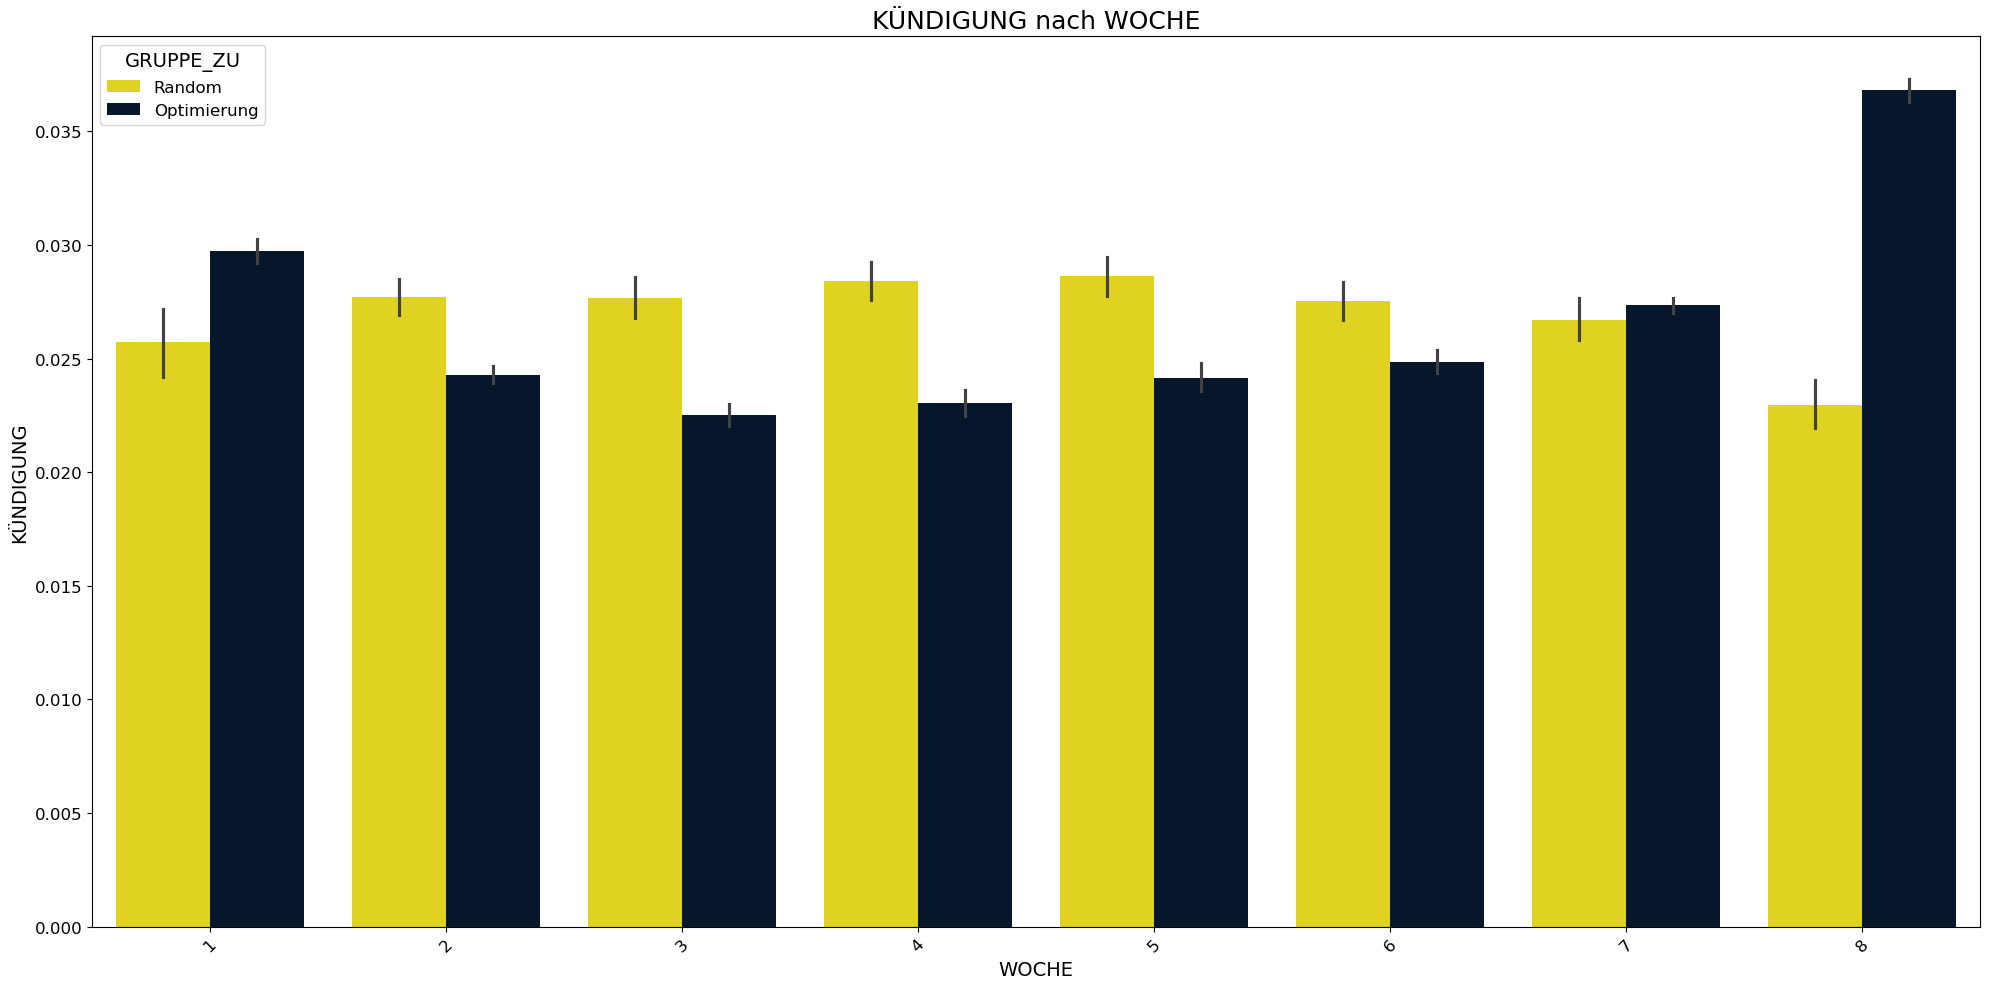

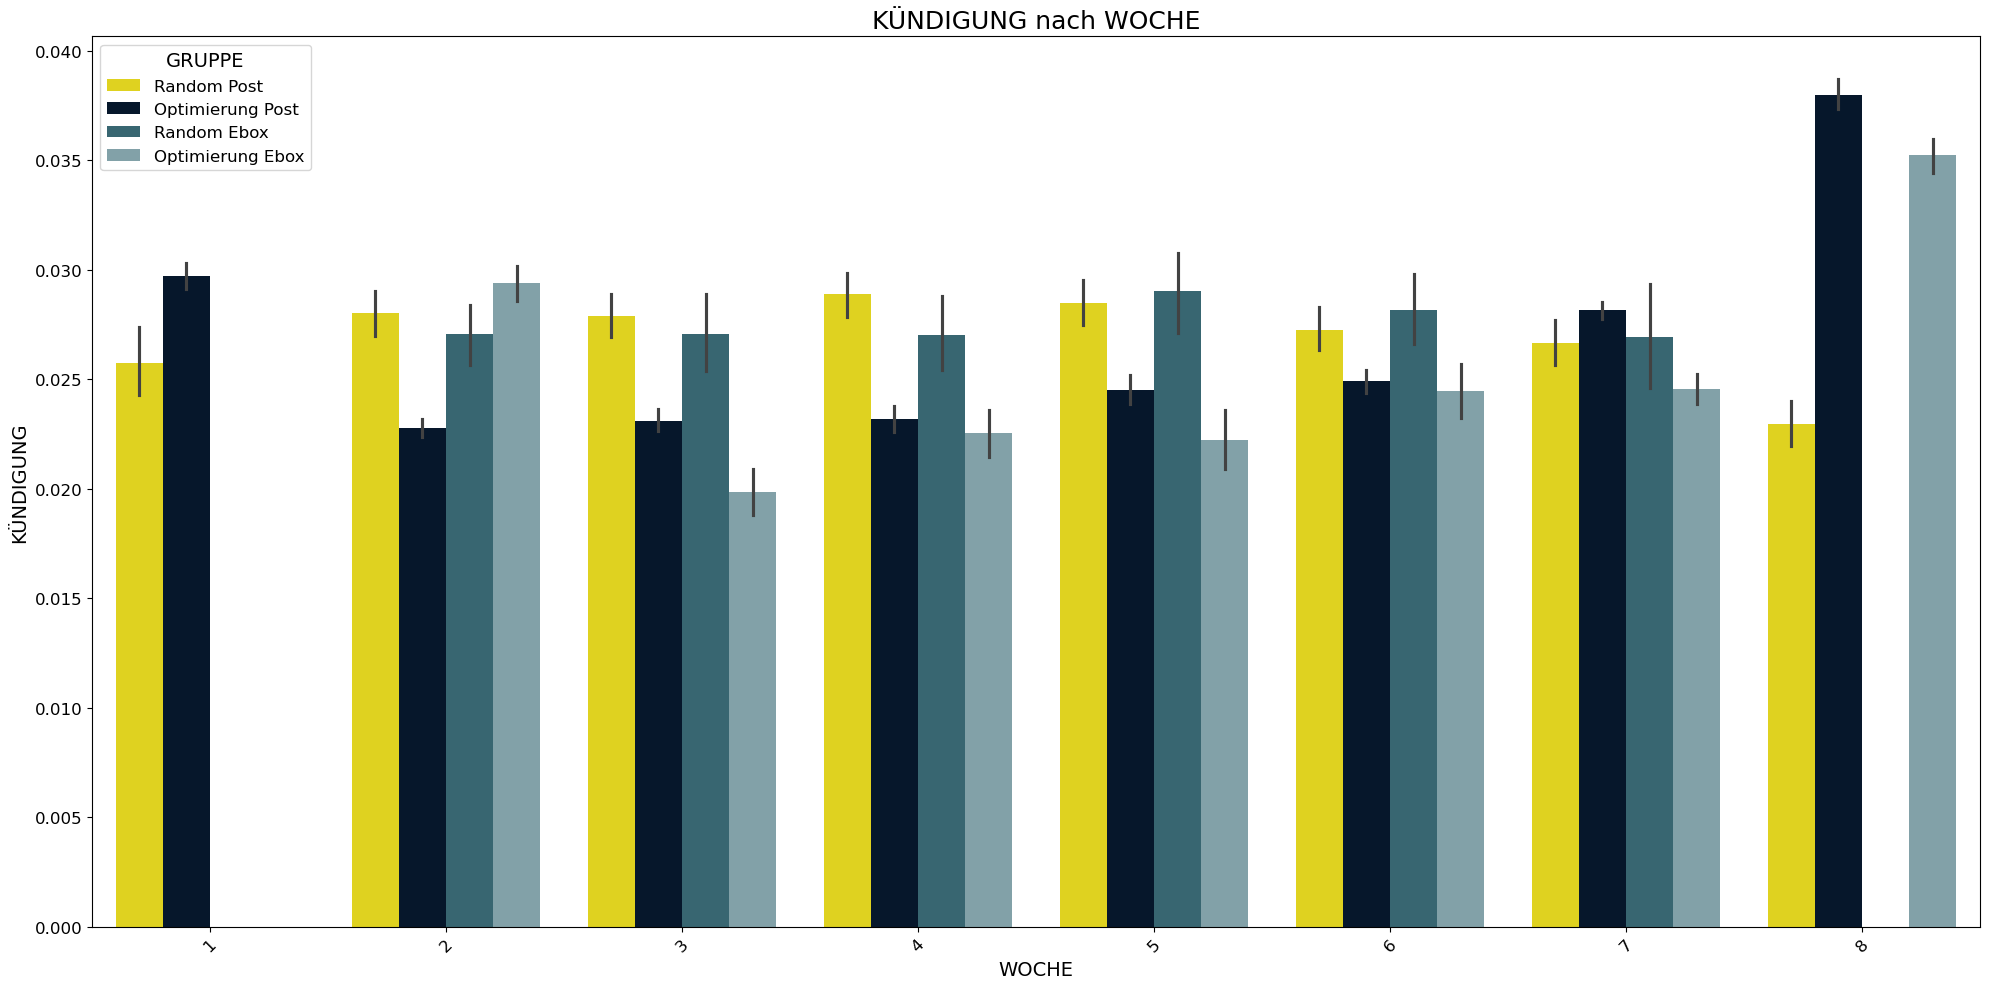

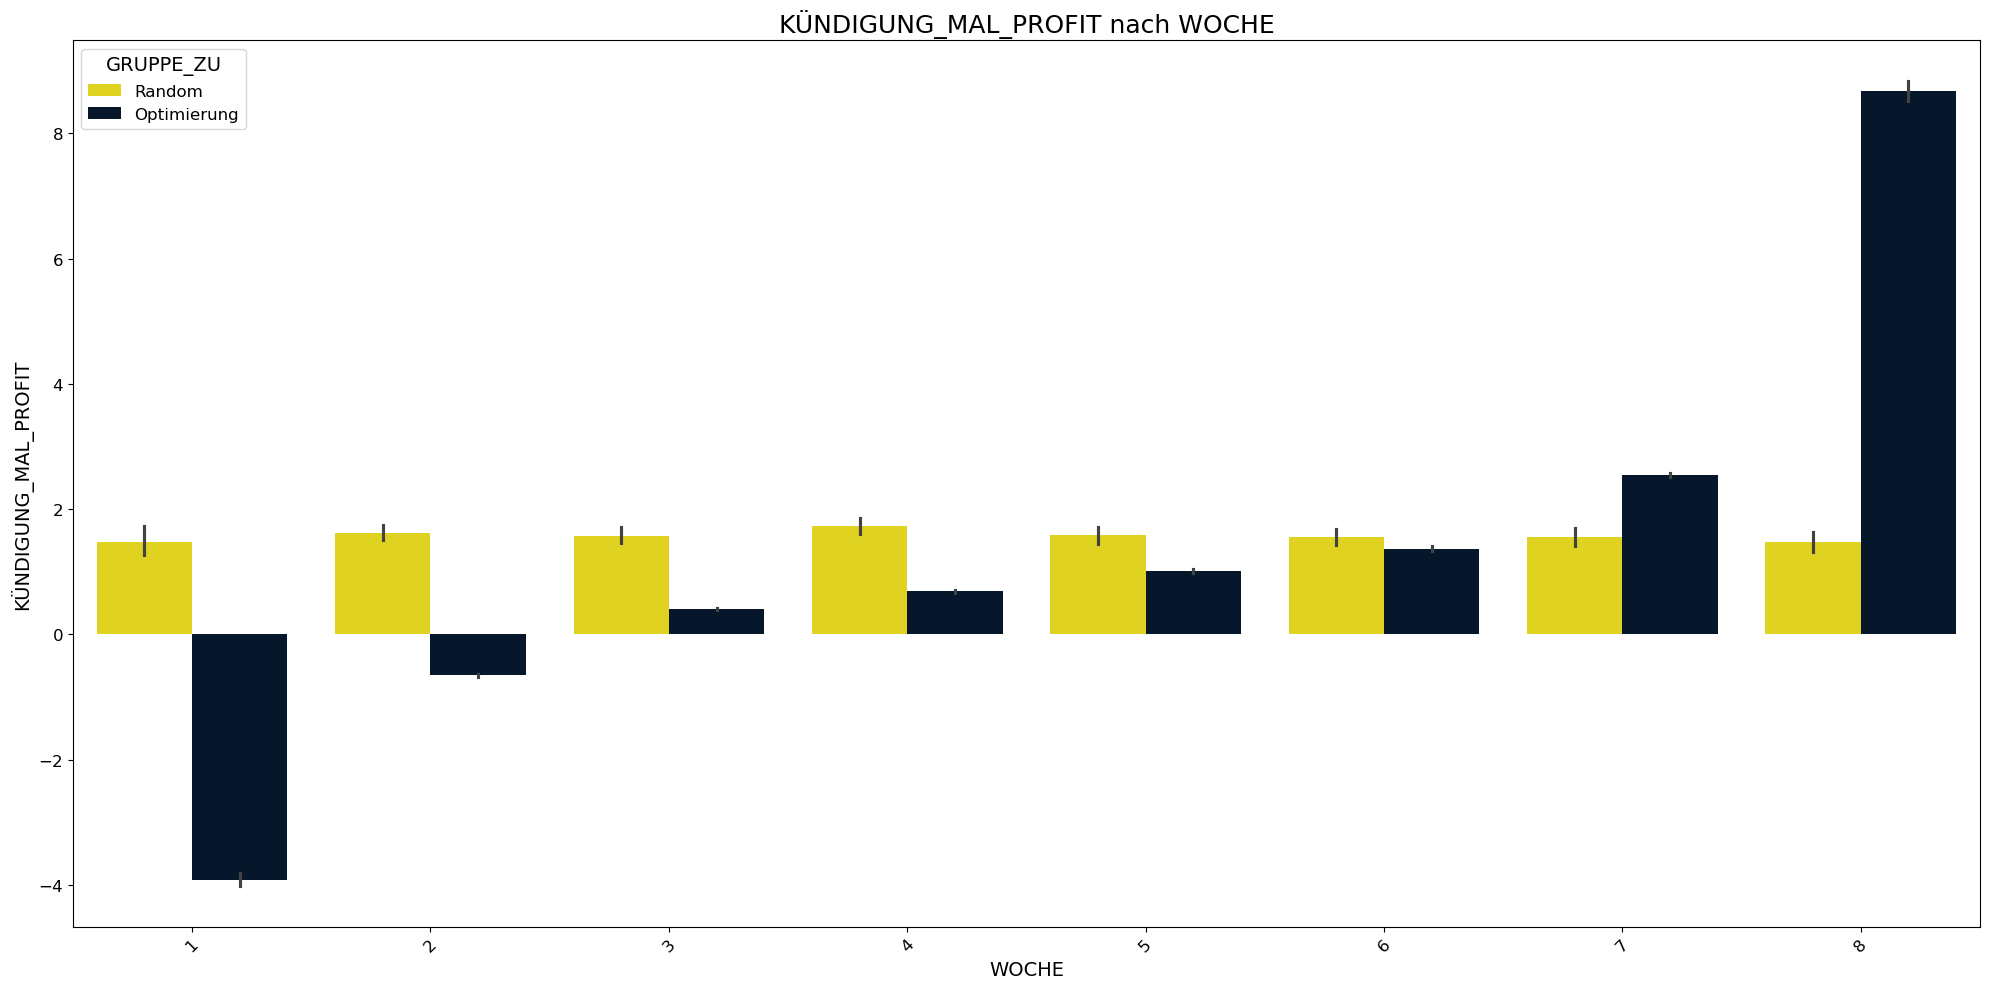

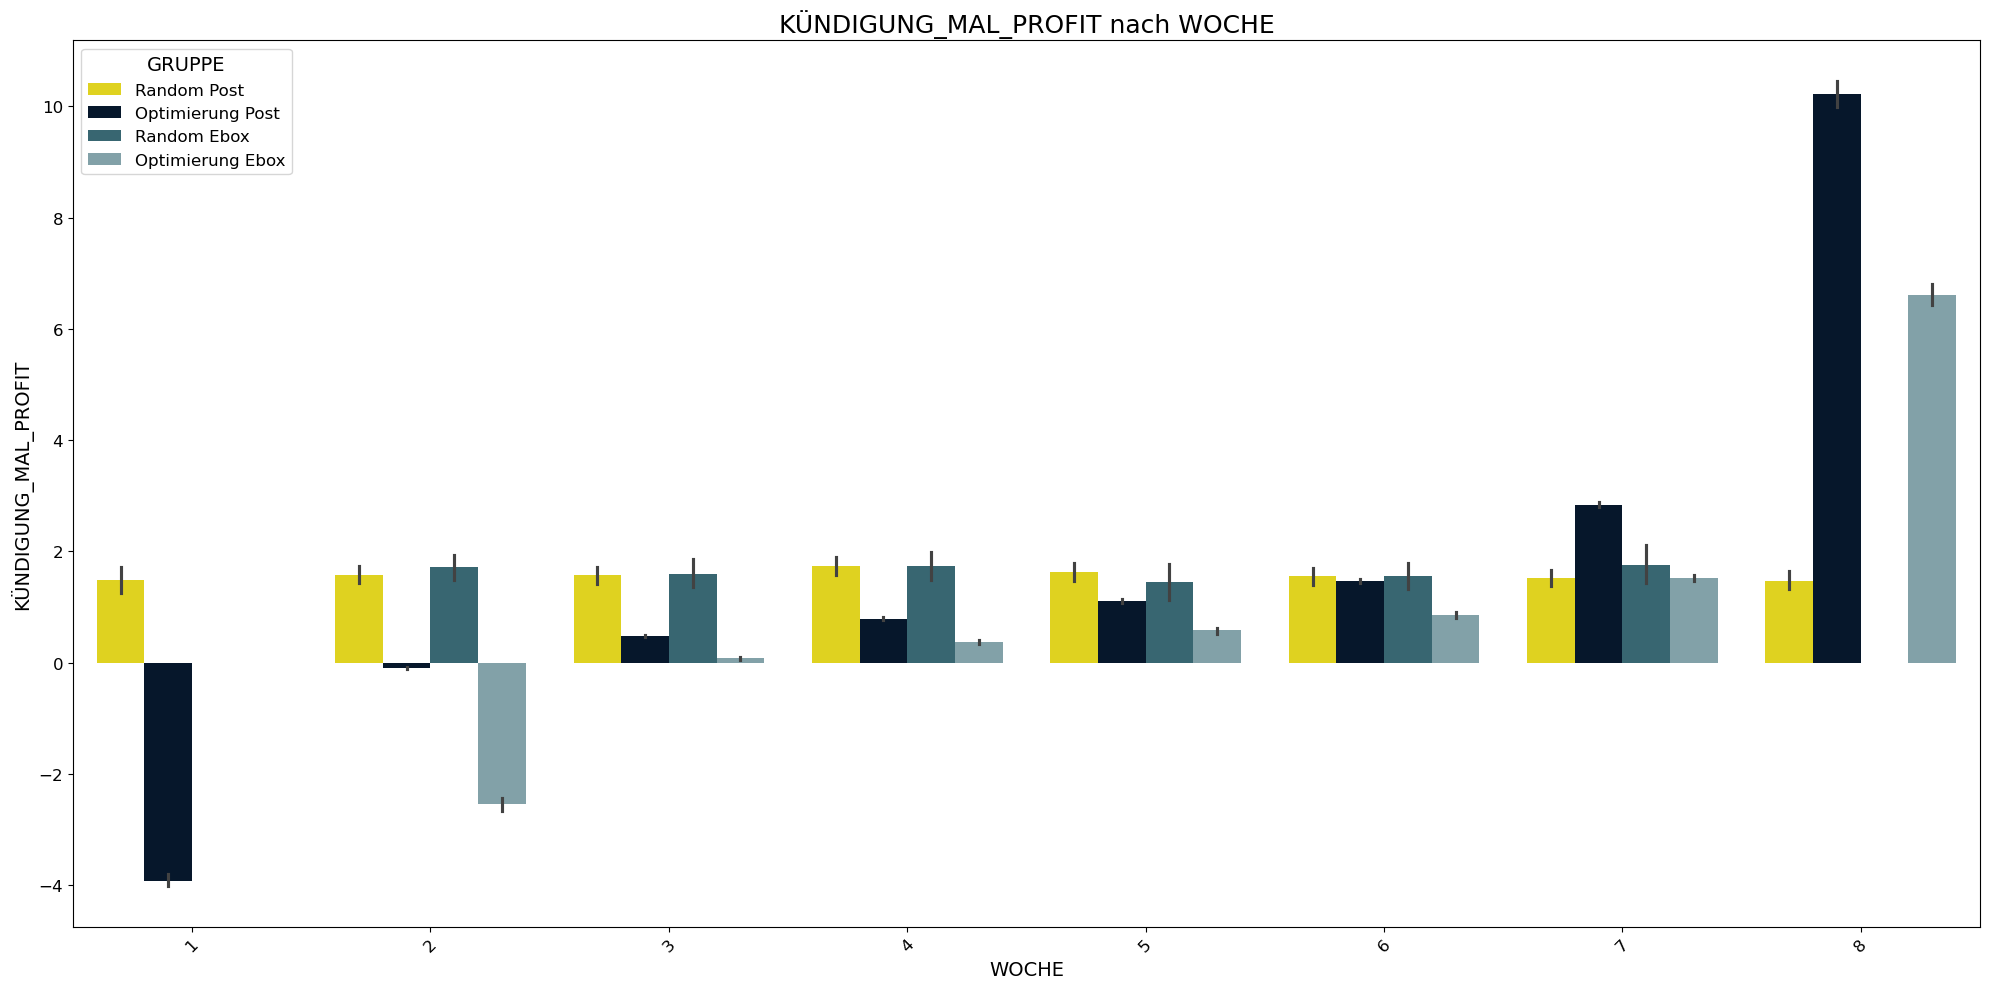

In [107]:
plot_kat_balken(df, x='WOCHE', y='KÜNDIGUNG', hue='GRUPPE_ZU')
plot_kat_balken(df, x='WOCHE', y='KÜNDIGUNG', hue='GRUPPE')
plot_kat_balken(df, x='WOCHE', y='KÜNDIGUNG_MAL_PROFIT', hue='GRUPPE_ZU')
plot_kat_balken(df, x='WOCHE', y='KÜNDIGUNG_MAL_PROFIT', hue='GRUPPE')

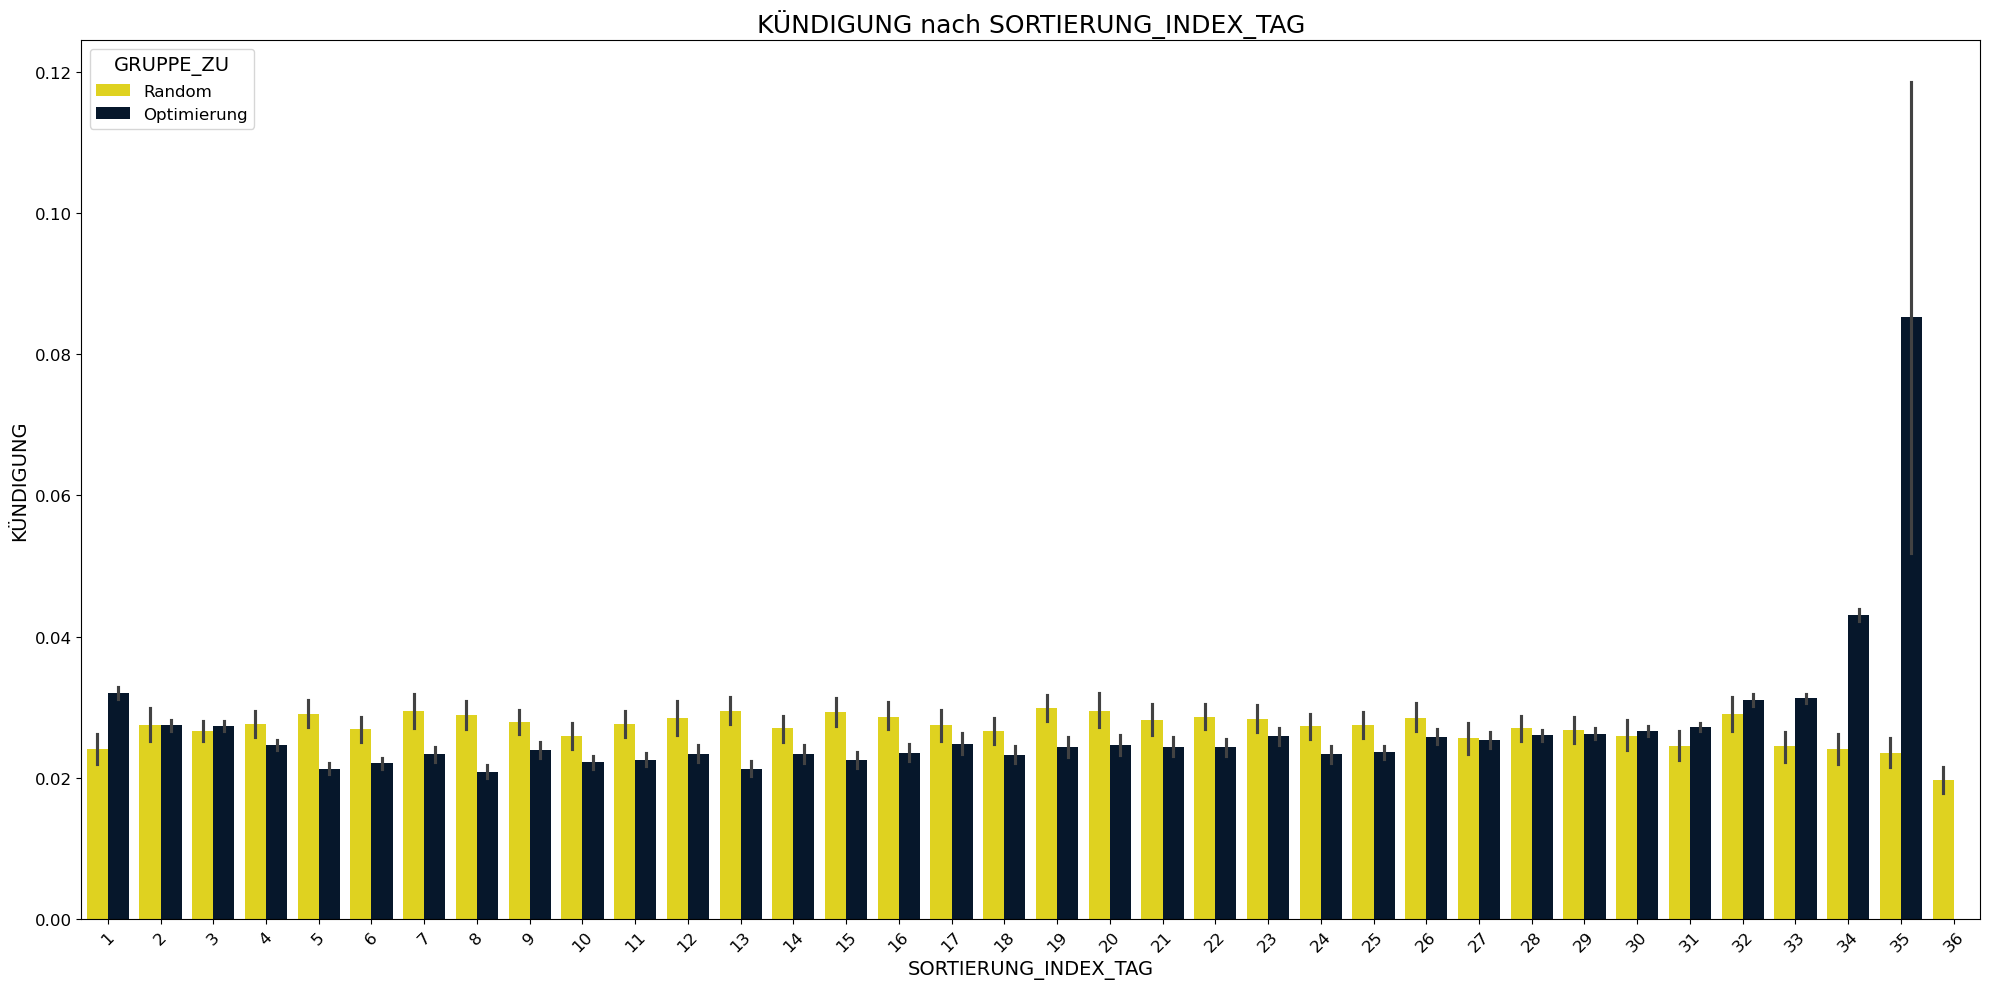

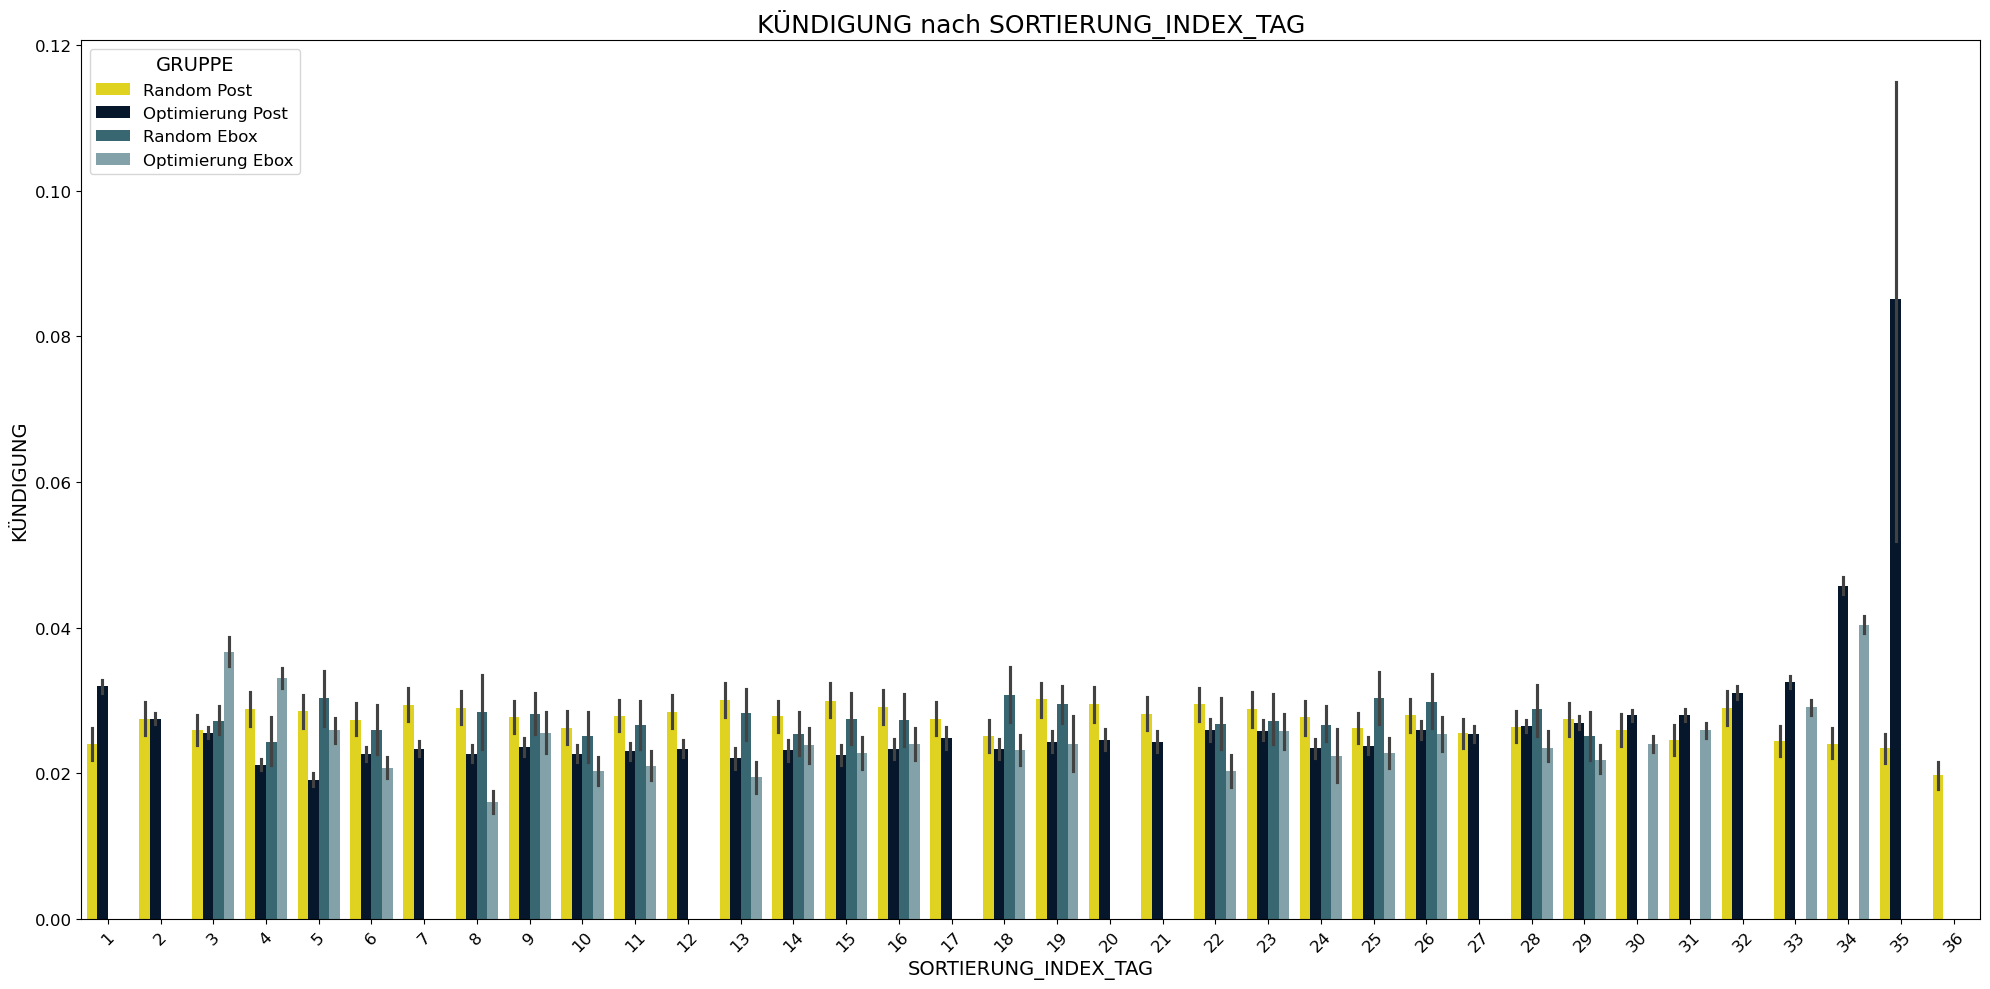

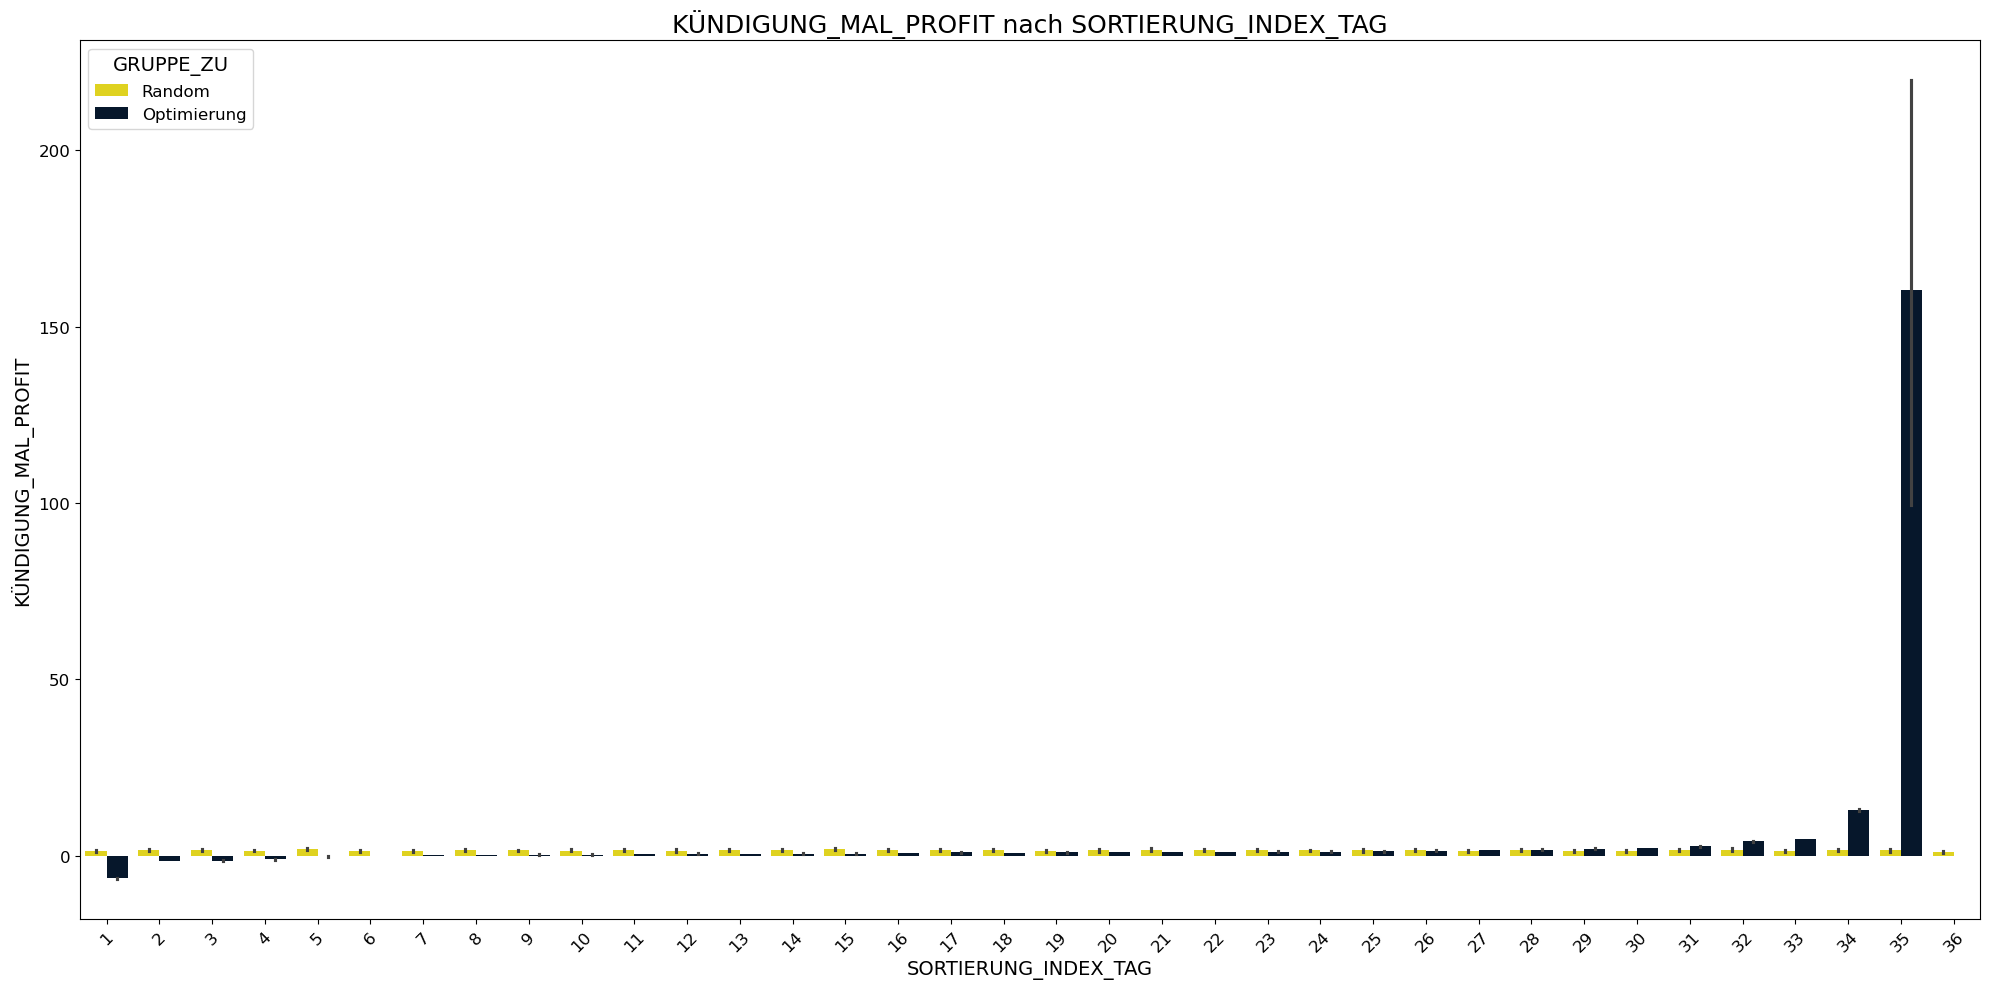

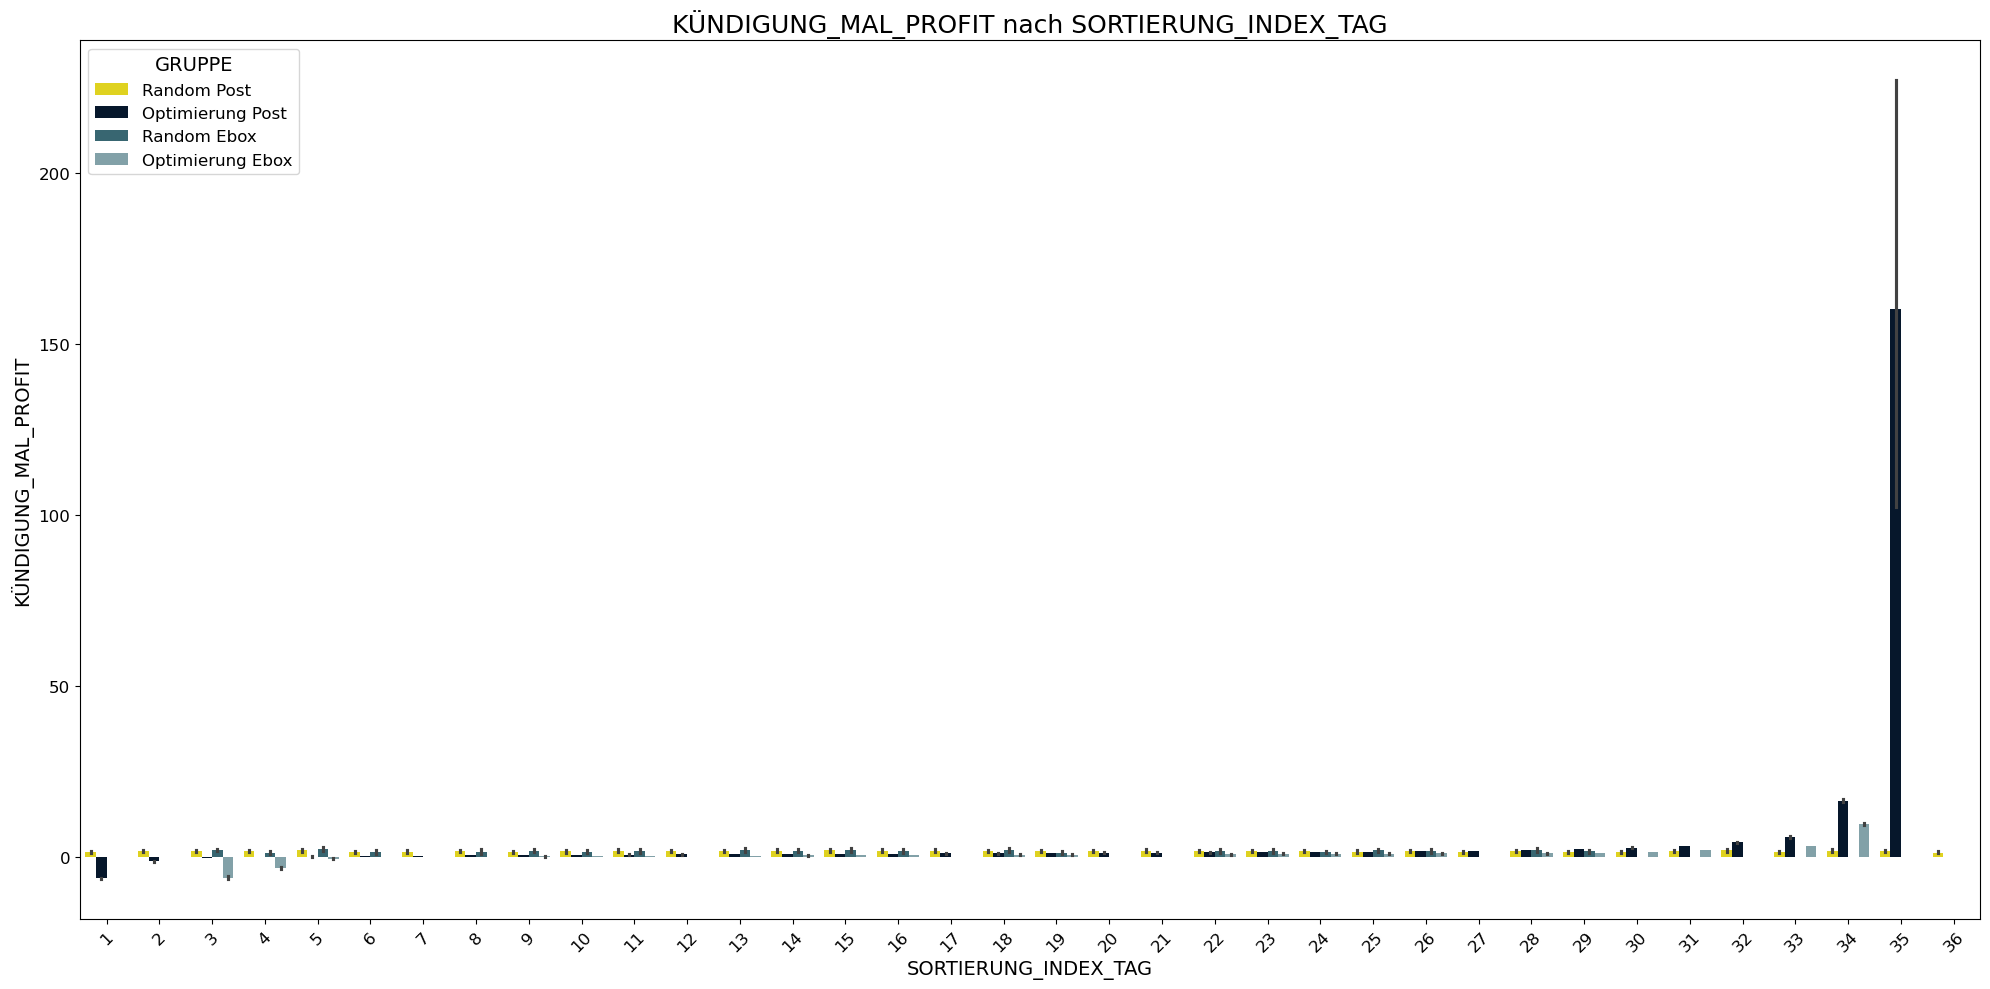

In [25]:
plot_kat_balken(df, x='SORTIERUNG_INDEX_TAG', y='KÜNDIGUNG', hue='GRUPPE_ZU')
plot_kat_balken(df, x='SORTIERUNG_INDEX_TAG', y='KÜNDIGUNG', hue='GRUPPE')
plot_kat_balken(df, x='SORTIERUNG_INDEX_TAG', y='KÜNDIGUNG_MAL_PROFIT', hue='GRUPPE_ZU')
plot_kat_balken(df, x='SORTIERUNG_INDEX_TAG', y='KÜNDIGUNG_MAL_PROFIT', hue='GRUPPE')

## Optimierung vs. Sortierung nach aufsteigender Partner_ID (Vertragsakte_ID) - POST

In [134]:
def simuliere_mehrwertgruppen(df, gruppe='Random Post', partner_id_col='DWH_PARTNER_ID', partner_bins=[0, 325, 674, 941, 1000], partner_labels=[1, 2, 3, 4], wochenspalte='WOCHE', wochen_bins=[0, 2, 4, 6, 8], wochen_labels=[1, 2, 3, 4]):
    """
    Führt die Gruppierung und Matching-Logik zur Simulation von Mehrwertgruppen durch.
    """
    import itertools
 
    df_sim = df[df['GRUPPE'] == gruppe].copy()
 
    # 1. Partner-ID in gleich große Gruppen einteilen
    df_sim = df_sim.sort_values(by=partner_id_col)
    df_sim['DWH_PARTNER_ID_CUT'] = pd.qcut(df_sim[partner_id_col], q=1000, labels=False) + 1
 
    # 2. Manuelle Gruppierung nach Partner-Gruppen
    df_sim = df_sim.sort_values(by='DWH_PARTNER_ID_CUT')
    df_sim['DWH_PARTNER_ID_GRUPPE'] = pd.cut(df_sim['DWH_PARTNER_ID_CUT'], bins=partner_bins, labels=partner_labels)
 
    # 3. Gruppierung nach Wochennummer
    df_sim = df_sim.sort_values(by=wochenspalte)
    df_sim['WOCHE_GRUPPE'] = pd.cut(df_sim[wochenspalte], bins=wochen_bins, labels=wochen_labels)
 
    return df_sim

In [135]:
def filtere_passende_simulation(df_sim):
    """
    Behalte nur Fälle, bei denen Partnergruppe == WOCHE_GRUPPE.
    """
    return df_sim[df_sim['DWH_PARTNER_ID_GRUPPE'] == df_sim['WOCHE_GRUPPE']]

In [136]:
mengenverteilung_kumuliert = dict(zip(mengenverteilung.keys(), itertools.accumulate(mengenverteilung.values())))
mengenverteilung_kumuliert

{1: 0.17417417417417416,
 2: 0.3258258258258258,
 3: 0.47897897897897895,
 4: 0.6741741741741741,
 5: 0.8183183183183182,
 6: 0.9414414414414414,
 7: 0.9999999999999999,
 8: 0.9999999999999999}

In [137]:
df_simuliert = simuliere_mehrwertgruppen(df, gruppe='Random Post', partner_id_col='DWH_PARTNER_ID', partner_bins=[0, 325, 674, 941, 1000], partner_labels=[1, 2, 3, 4], wochenspalte='WOCHE', wochen_bins=[0, 2, 4, 6, 8], wochen_labels=[1, 2, 3, 4])

In [138]:
df_simuliert = filtere_passende_simulation(df_simuliert)

In [139]:
df_simuliert

,DWH_PARTNER_ID,vnr,DWH_VERTRAGSAKTE_ID,SORTIERUNG_INDEX_TAG,GRUPPE,EBOX_J_BLK,QUELLE_VERSAND,ve_id_dwh,ve_profit,VERTRAGSAKTE_ID,ANZ_ECHTER_ABGANG,KÜNDIGUNG,GRUPPE_ZU,KÜNDIGUNG_MAL_PROFIT,WOCHE,ZEITRAUM,MENGENVERTEILUNG_FÜR_POLICY,DWH_PARTNER_ID_CUT,DWH_PARTNER_ID_GRUPPE,WOCHE_GRUPPE
1582774,45854447,501526990,113689618,2,Random Post,P,POST,113689618,-455.629425,<NA>,NaN,0,Random,-0.0,1,0,0.174174,56,1,1
877881,45856610,646425061,1308199472,2,Random Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Random,0.0,1,0,0.174174,56,1,1
1264699,45856698,602202004,160274765,1,Random Post,P,POST,160274765,7.763265,<NA>,NaN,0,Random,0.0,1,0,0.174174,56,1,1
881263,45856610,646425062,1308199125,2,Random Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Random,0.0,1,0,0.174174,56,1,1
876095,45856610,646425064,1308199014,2,Random Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Random,0.0,1,0,0.174174,56,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575296,2422555077,501975581,1469221589,33,Random Post,P,POST,1469221589,-27.274812,<NA>,NaN,0,Random,-0.0,8,2,0.000000,1000,4,4
1366685,2413161926,534373090,141812538,34,Random Post,P,POST,141812538,-0.083877,<NA>,NaN,0,Random,-0.0,8,2,0.000000,1000,4,4
1026889,2409534698,630553991,1463690186,34,Random Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Random,0.0,8,2,0.000000,1000,4,4
951074,2447260536,638806738,1529600565,35,Random Post,P,POST,<NA>,0.000000,<NA>,NaN,0,Random,0.0,8,2,0.000000,1000,4,4


### Mehrwert in Optimierung

In [140]:
def berechne_simulationsmehrwert(
    df_sim,
    spalte,
    df_optimierung,
    skaliere_mit_anzahl=True
):
    """
    Vergleicht simulierte Gruppe mit Optimierungsgruppe bzgl. einer Zielgröße.
    """
    sim_mw = df_sim[spalte].mean()
    opt_mw = df_optimierung[spalte].mean()
    delta = sim_mw - opt_mw
    mehrwert = delta * len(df_optimierung) if skaliere_mit_anzahl else delta
 
    return {
        "Ø Simulation": round(sim_mw, 4),
        "Ø Optimierung": round(opt_mw, 4),
        "Delta Durchschnittstarget": round(delta, 4),
        "Delta Gesamttarget": round(mehrwert, 0)
    }

In [141]:
def berechne_simulationsmehrwertübersicht(df_sim, df_optimierung):
    """
    Erzeugt eine Tabelle mit Mehrwerten der Simulation im Vergleich zur Optimierung.
    Betrachtet: Kündigungen & Kündigung × Profit
    """
    ergebnisse = []
 
    metrik_liste = [
        ('KÜNDIGUNG', 'Kündigungen'),
        ('KÜNDIGUNG_MAL_PROFIT', 'Kündigung × Profit')
    ]
 
    for spalte, beschreibung in metrik_liste:
        result = berechne_simulationsmehrwert(
            df_sim,
            spalte=spalte,
            df_optimierung=df_optimierung
        )
        result["Metrik"] = beschreibung
        ergebnisse.append(result)
 
    return pd.DataFrame(ergebnisse)[[
        "Metrik",
        "Ø Optimierung",
        "Ø Simulation",
        "Delta Durchschnittstarget",
        "Delta Gesamttarget"
    ]]

In [142]:
df_opt = df[df['GRUPPE'] == 'Optimierung Post']
df_sim_gewichtung_post = df_simuliert  # z. B. nach Gruppierung & Filterung

df_sim_tab = berechne_simulationsmehrwertübersicht(df_sim_gewichtung_post, df_opt)
df_sim_tab

,Metrik,Ø Optimierung,Ø Simulation,Delta Durchschnittstarget,Delta Gesamttarget
0,Kündigungen,0.0268,0.0286,0.0018,5275.0
1,Kündigung × Profit,1.5656,1.6795,0.1139,339860.0


In [143]:
df_opt['ve_profit'].mean()

44.88134796258497

In [144]:
df_simuliert['ve_profit'].mean()

45.32313391518682

### Signifikanztests

In [145]:
def konfidenzintervall(data, conf_level=0.95):
    """Berechnet ein Konfidenzintervall für eine gegebene Stichprobe."""
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    n = len(data)
    t_crit = t.ppf((1 + conf_level) / 2, df=n-1)
    margin_of_error = t_crit * (std / np.sqrt(n))
    return mean - margin_of_error, mean + margin_of_error

In [146]:
def test_signifikanz_und_konfidenzintervall_df(
    df1,
    df2,
    spalte,
    beschreibung=None,
    label1='Gruppe 1',
    label2='Gruppe 2',
    konfidenzniveau=0.95,
    filter1=None,
    filter2=None
):
    """
    Führt einen t-Test zwischen zwei DataFrames durch und gibt Konfidenzintervalle sowie Signifikanz aus.
    Optional: mit Filterbedingung je Gruppe.
    """
    d1 = df1.query(filter1) if filter1 else df1
    d2 = df2.query(filter2) if filter2 else df2
 
    werte1 = d1[spalte].dropna()
    werte2 = d2[spalte].dropna()
 
    stat, p_value = ttest_ind(werte1, werte2, equal_var=False)
    ci1 = konfidenzintervall(werte1, conf_level=konfidenzniveau)
    ci2 = konfidenzintervall(werte2, conf_level=konfidenzniveau)
 
    beschreibung = beschreibung or spalte
    print(f"\n📊 Signifikanztest für: {beschreibung}")
    print(f"➤ Mittelwert {label1}: {werte1.mean():.4f}, Konfidenzintervall: {ci1}")
    print(f"➤ Mittelwert {label2}: {werte2.mean():.4f}, Konfidenzintervall: {ci2}")
    print(f"→ T-Wert: {stat:.3f}, P-Wert: {p_value:.4f}")
    if p_value < 0.05:
        print("🚩 Die Mittelwerte sind signifikant unterschiedlich.")
    else:
        print("⏸️ Kein signifikanter Unterschied zwischen den Mittelwerten.")

In [147]:
test_signifikanz_und_konfidenzintervall_df(
    df1=df_opt,
    df2=df_sim_gewichtung_post,
    spalte='KÜNDIGUNG',
    beschreibung='Kündigungsquote (simuliert vs. optimiert)',
    label1='Optimierung',
    label2='Simulation'
)
 
test_signifikanz_und_konfidenzintervall_df(
    df1=df_opt,
    df2=df_sim_gewichtung_post,
    spalte='KÜNDIGUNG_MAL_PROFIT',
    beschreibung='Kündigung × Profit (simuliert vs. optimiert)',
    label1='Optimierung',
    label2='Simulation'
)
 
test_signifikanz_und_konfidenzintervall_df(
    df1=df_opt,
    df2=df_sim_gewichtung_post,
    spalte='ve_profit',
    filter1='KÜNDIGUNG == 1',
    filter2='KÜNDIGUNG == 1',
    beschreibung='Profit bei Kündigung (simuliert vs. optimiert)',
    label1='Optimierung',
    label2='Simulation'
)


📊 Signifikanztest für: Kündigungsquote (simuliert vs. optimiert)
➤ Mittelwert Optimierung: 0.0268, Konfidenzintervall: (0.026614140098606267, 0.026980651738112007)
➤ Mittelwert Simulation: 0.0286, Konfidenzintervall: (0.027806863882336386, 0.02932457191232321)
→ T-Wert: -4.440, P-Wert: 0.0000
🚩 Die Mittelwerte sind signifikant unterschiedlich.

📊 Signifikanztest für: Kündigung × Profit (simuliert vs. optimiert)
➤ Mittelwert Optimierung: 1.5656, Konfidenzintervall: (1.536961228251148, 1.5942474150469796)
➤ Mittelwert Simulation: 1.6795, Konfidenzintervall: (1.5625314201337965, 1.796529452411649)
→ T-Wert: -1.854, P-Wert: 0.0638
⏸️ Kein signifikanter Unterschied zwischen den Mittelwerten.

📊 Signifikanztest für: Profit bei Kündigung (simuliert vs. optimiert)
➤ Mittelwert Optimierung: 58.4237, Konfidenzintervall: (57.43233101073507, 59.41516614300539)
➤ Mittelwert Simulation: 58.7953, Konfidenzintervall: (55.007850570706125, 62.582783230919304)
→ T-Wert: -0.186, P-Wert: 0.8524
⏸️ Kein si

## Optimierung vs. Sortierung nach aufsteigender Partner_ID (Vertragsakte_ID) - EBOX

In [148]:
mengenverteilung_kumuliert = dict(zip(mengenverteilung.keys(), itertools.accumulate(mengenverteilung.values())))
mengenverteilung_kumuliert

{1: 0.17417417417417416,
 2: 0.3258258258258258,
 3: 0.47897897897897895,
 4: 0.6741741741741741,
 5: 0.8183183183183182,
 6: 0.9414414414414414,
 7: 0.9999999999999999,
 8: 0.9999999999999999}

In [205]:
df_simuliert = simuliere_mehrwertgruppen(df, gruppe='Random Ebox', partner_id_col='DWH_PARTNER_ID', partner_bins=[0, 325, 674, 941, 1000], partner_labels=[1, 2, 3, 4], wochenspalte='WOCHE', wochen_bins=[0, 2, 4, 6, 8], wochen_labels=[1, 2, 3, 4])

In [206]:
df_simuliert = filtere_passende_simulation(df_simuliert)

In [207]:
df_simuliert

,DWH_PARTNER_ID,vnr,DWH_VERTRAGSAKTE_ID,SORTIERUNG_INDEX_TAG,GRUPPE,EBOX_J_BLK,QUELLE_VERSAND,ve_id_dwh,ve_profit,VERTRAGSAKTE_ID,ANZ_ECHTER_ABGANG,KÜNDIGUNG,GRUPPE_ZU,KÜNDIGUNG_MAL_PROFIT,WOCHE,ZEITRAUM,MENGENVERTEILUNG_FÜR_POLICY,DWH_PARTNER_ID_CUT,DWH_PARTNER_ID_GRUPPE,WOCHE_GRUPPE
4691337,51820230,621159951,182385168,5,Random Ebox,E,EBOX,182385168,63.617790,<NA>,NaN,0,Random,0.0,2,0,0.151652,191,1,1
4607605,51815026,601511010,158517386,3,Random Ebox,E,EBOX,158517386,-8.352537,<NA>,NaN,0,Random,-0.0,2,0,0.151652,191,1,1
4720893,51777566,643163438,203662956,3,Random Ebox,E,EBOX,203662956,17.995632,<NA>,NaN,0,Random,0.0,2,0,0.151652,191,1,1
4618210,43709728,546018994,149270578,3,Random Ebox,E,EBOX,149270578,-0.866905,<NA>,NaN,0,Random,-0.0,2,0,0.151652,1,1,1
4662224,51783036,629313405,187763705,3,Random Ebox,E,EBOX,187763705,16.322837,<NA>,NaN,0,Random,0.0,2,0,0.151652,191,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4720077,2407318778,620930867,1535527373,28,Random Ebox,E,EBOX,1535527373,121.891400,<NA>,NaN,0,Random,0.0,7,2,0.058559,1000,4,4
4585837,2407117876,618323757,1535331667,28,Random Ebox,E,EBOX,1535331667,70.337597,<NA>,NaN,0,Random,0.0,7,2,0.058559,1000,4,4
4619699,2417643952,629683423,478077608,28,Random Ebox,E,EBOX,478077608,257.430836,<NA>,NaN,0,Random,0.0,7,2,0.058559,1000,4,4
4710711,2420005563,628453972,1260258365,28,Random Ebox,E,EBOX,1260258365,539.872304,<NA>,NaN,0,Random,0.0,7,2,0.058559,1000,4,4


### Mehrwert in Optimierung

In [208]:
df_opt = df[df['GRUPPE'] == 'Optimierung Ebox']
df_sim_gewichtung_ebox = df_simuliert  # z. B. nach Gruppierung & Filterung
 
df_sim_tab = berechne_simulationsmehrwertübersicht(df_sim_gewichtung_ebox, df_opt)
df_sim_tab

,Metrik,Ø Optimierung,Ø Simulation,Delta Durchschnittstarget,Delta Gesamttarget
0,Kündigungen,0.0276,0.0271,-0.0005,-424.0
1,Kündigung × Profit,1.7261,1.6587,-0.0673,-56771.0


In [209]:
df_opt['ve_profit'].mean()

48.725365010608634

In [210]:
df_simuliert['ve_profit'].mean()

48.35474616171019

### Signifikanztests

In [213]:
test_signifikanz_und_konfidenzintervall_df(
    df1=df_opt,
    df2=df_sim_gewichtung_ebox,
    spalte='KÜNDIGUNG',
    beschreibung='Kündigungsquote (simuliert vs. optimiert)',
    label1='Optimierung',
    label2='Simulation'
)
 
test_signifikanz_und_konfidenzintervall_df(
    df1=df_opt,
    df2=df_sim_gewichtung_ebox,
    spalte='KÜNDIGUNG_MAL_PROFIT',
    beschreibung='Kündigung × Profit (simuliert vs. optimiert)',
    label1='Optimierung',
    label2='Simulation'
)
 
test_signifikanz_und_konfidenzintervall_df(
    df1=df_opt,
    df2=df_sim_gewichtung_ebox,
    spalte='ve_profit',
    filter1='KÜNDIGUNG == 1',
    filter2='KÜNDIGUNG == 1',
    beschreibung='Profit bei Kündigung (simuliert vs. optimiert)',
    label1='Optimierung',
    label2='Simulation'
)


📊 Signifikanztest für: Kündigungsquote (simuliert vs. optimiert)
➤ Mittelwert Optimierung: 0.0276, Konfidenzintervall: (0.02725302455560122, 0.027952471795664215)
➤ Mittelwert Simulation: 0.0271, Konfidenzintervall: (0.02564560953571153, 0.028554027184751127)
→ T-Wert: 0.659, P-Wert: 0.5099
⏸️ Kein signifikanter Unterschied zwischen den Mittelwerten.

📊 Signifikanztest für: Kündigung × Profit (simuliert vs. optimiert)
➤ Mittelwert Optimierung: 1.7261, Konfidenzintervall: (1.669459200119474, 1.7827097449470315)
➤ Mittelwert Simulation: 1.6587, Konfidenzintervall: (1.4356616969702487, 1.8818236745835186)
→ T-Wert: 0.573, P-Wert: 0.5663
⏸️ Kein signifikanter Unterschied zwischen den Mittelwerten.

📊 Signifikanztest für: Profit bei Kündigung (simuliert vs. optimiert)
➤ Mittelwert Optimierung: 62.5331, Konfidenzintervall: (60.6406644459966, 64.42546748770802)
➤ Mittelwert Simulation: 61.2086, Konfidenzintervall: (53.65076746692843, 68.76648741851905)
→ T-Wert: 0.333, P-Wert: 0.7388
⏸️ Kein

# Plot Strategie Vergleiche

In [214]:
def plot_wochenkennzahlen_pro_strategie(df, strategie_name, wochenspalte='WOCHE', partner_id_col='DWH_PARTNER_ID'):
    """
    Plottet Wochenbalkendiagramme für eine gegebene Versandstrategie.
    Dargestellt werden:
    - Ø Partner-ID
    - Ø Profitabilität
    - Ø Kündigungsquote
    - Ø Kündigung × Profit
    """
    metrics = {
        'DWH_PARTNER_ID': 'Ø Partner-ID',
        've_profit': 'Ø Profitabilität',
        'KÜNDIGUNG': 'Ø Kündigungsquote',
        'KÜNDIGUNG_MAL_PROFIT': 'Ø Kündigung × Profit'
    }
 
    for spalte, y_label in metrics.items():
        plt.figure(figsize=(14, 6))
        sns.barplot(
            data=df,
            x=wochenspalte,
            y=spalte,
            ci=None,
            palette='rainbow'
        )
        plt.title(f'{y_label} je Woche – {strategie_name}', fontsize=16)
        plt.xlabel("Woche", fontsize=13)
        plt.ylabel(y_label, fontsize=13)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [215]:
def plot_wochenkennzahlen_pro_strategie(df, strategie_name, wochenspalte='WOCHE', partner_id_col='DWH_PARTNER_ID'):
    """
    Plottet pro Woche:
    - Ø Partner-ID
    - Ø Profitabilität
    - Ø Kündigungsquote
    - Ø Kündigung × Profit
    inkl. Anzeige der Fallzahlen pro Woche.
    """
    import seaborn as sns
    import matplotlib.pyplot as plt
 
    metrics = {
        'DWH_PARTNER_ID': 'Ø Partner-ID',
        've_profit': 'Ø Profitabilität',
        'KÜNDIGUNG': 'Ø Kündigungsquote',
        'KÜNDIGUNG_MAL_PROFIT': 'Ø Kündigung × Profit'
    }
 
    for spalte, y_label in metrics.items():
        df_agg = df.groupby(wochenspalte).agg(
            mittelwert=(spalte, 'mean'),
            anzahl=(spalte, 'count')
        ).reset_index()
 
        plt.figure(figsize=(14, 6))
        ax = sns.barplot(
            data=df_agg,
            x=wochenspalte,
            y='mittelwert',
            ci=None,
            palette='rainbow'
        )
        plt.title(f'{y_label} je Woche – {strategie_name}', fontsize=16)
        plt.xlabel("Woche", fontsize=13)
        plt.ylabel(y_label, fontsize=13)
 
        # Fallzahlen über den Balken anzeigen
        for i, row in df_agg.iterrows():
            ax.text(i, row['mittelwert'], f'n={row["anzahl"]}', ha='center', va='bottom', fontsize=10, color='black')
 
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



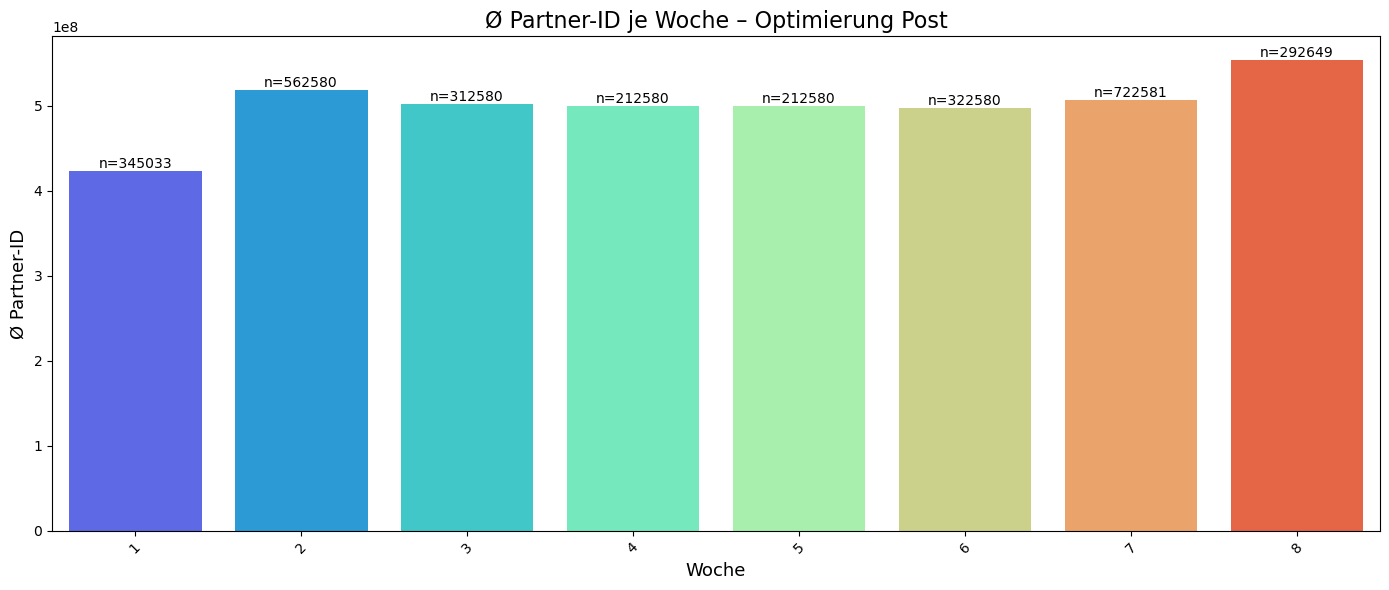



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



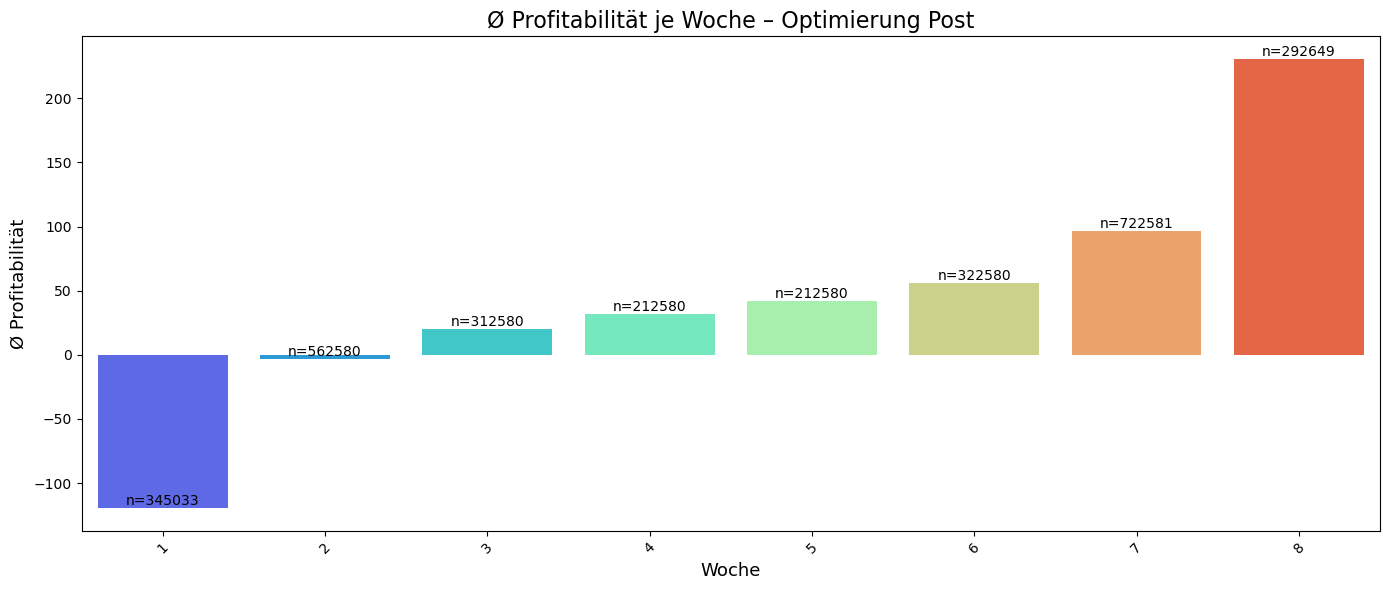



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



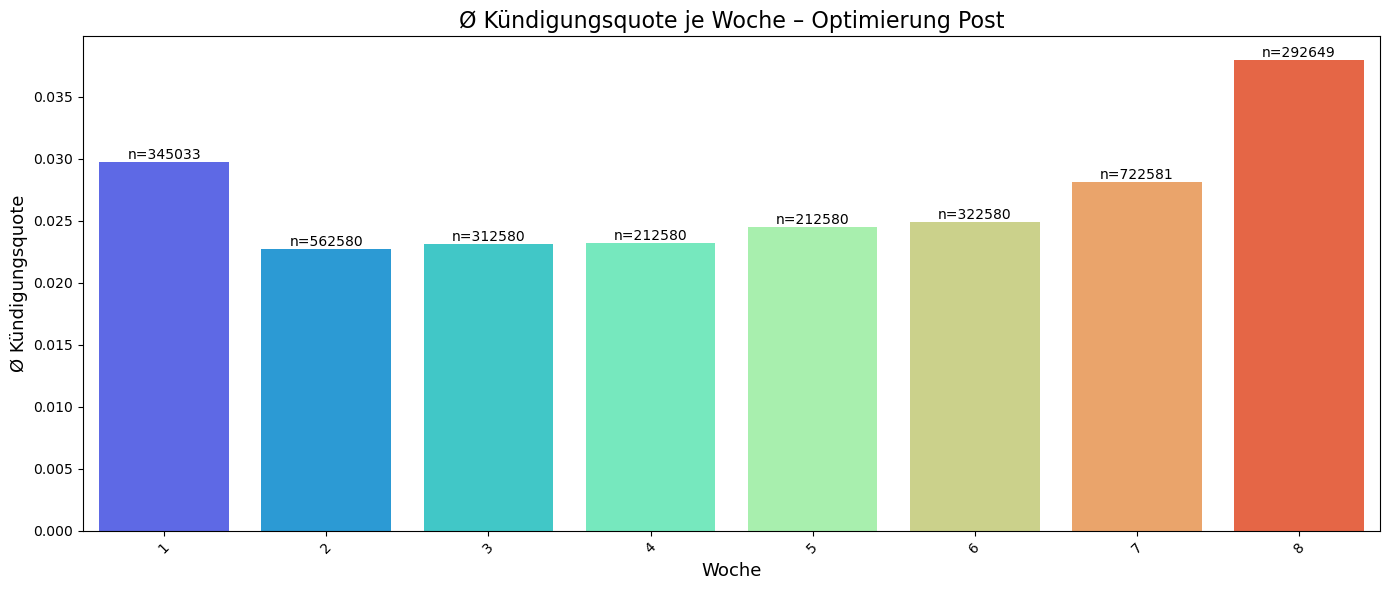



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



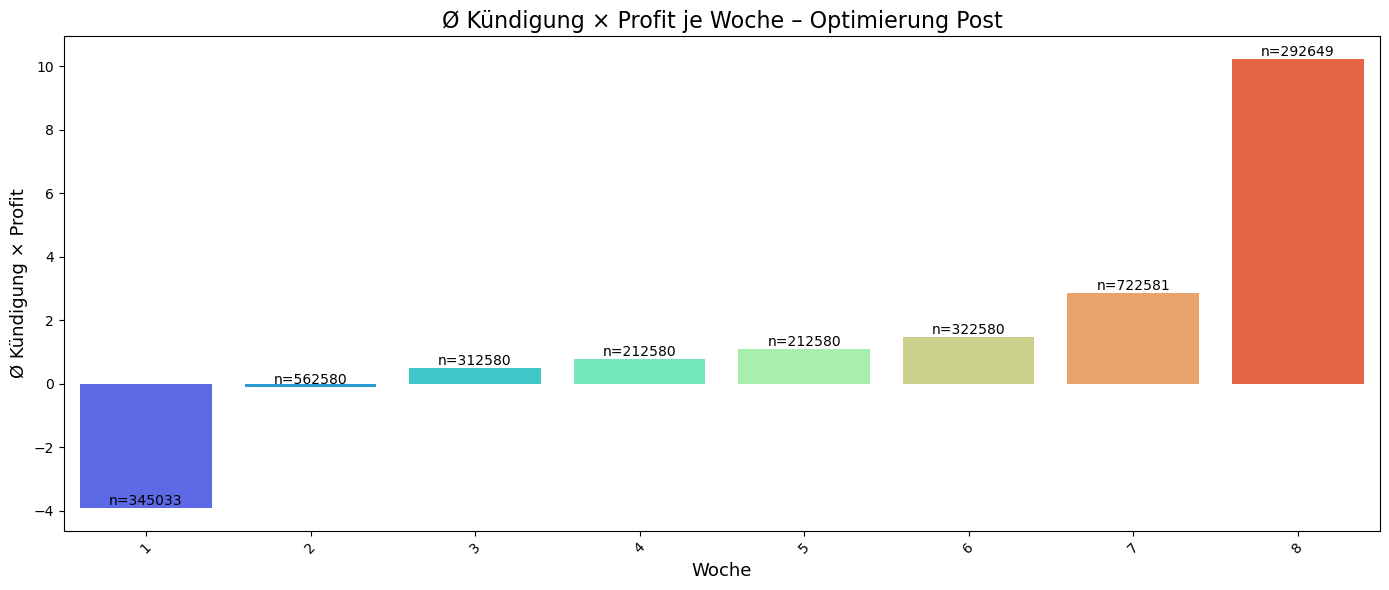

In [226]:
plot_wochenkennzahlen_pro_strategie(df[df['GRUPPE'] == 'Optimierung Post'], "Optimierung Post")



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



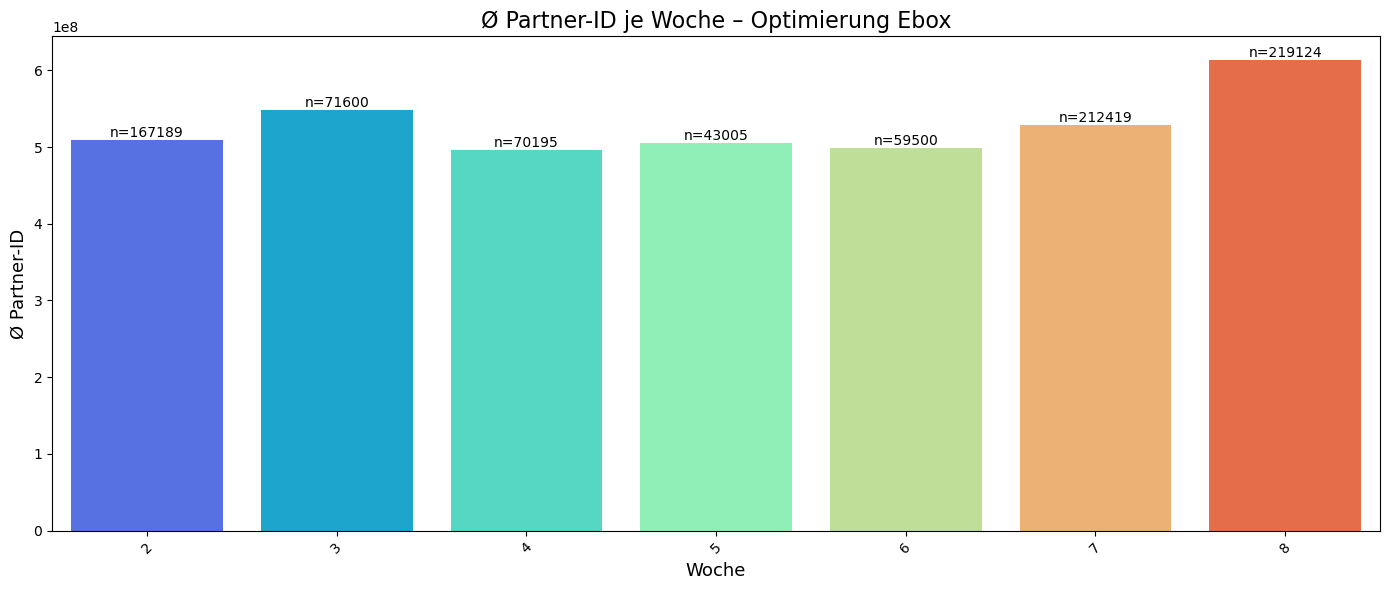



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



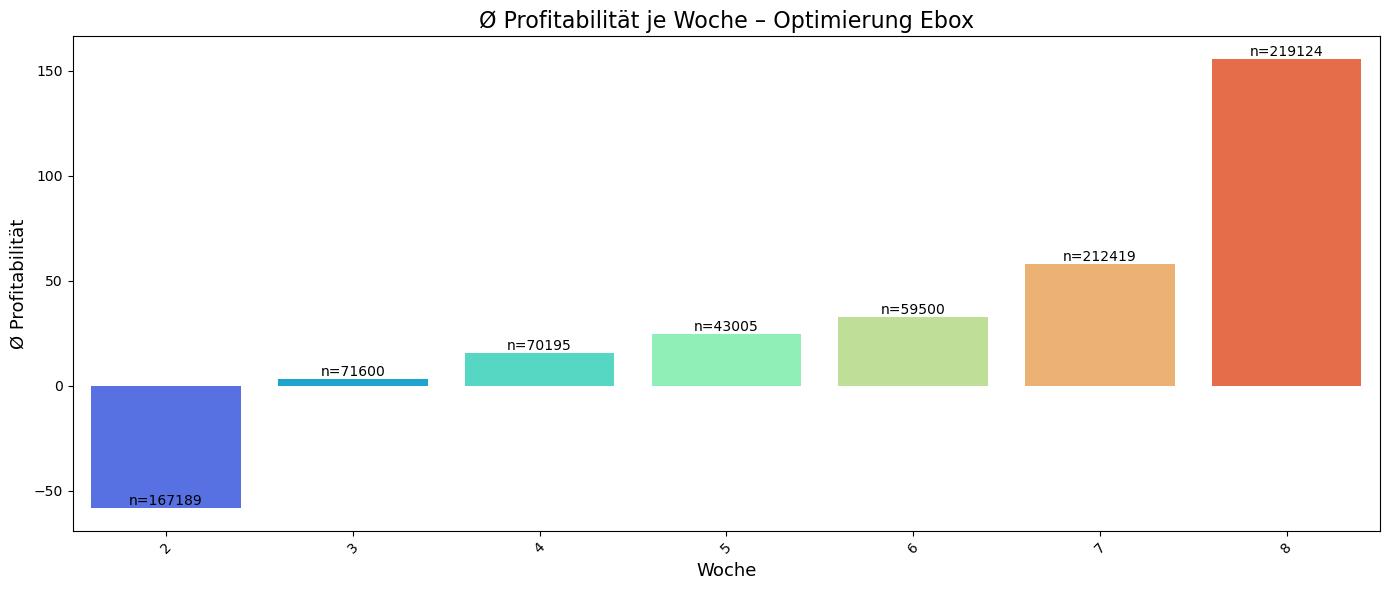



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



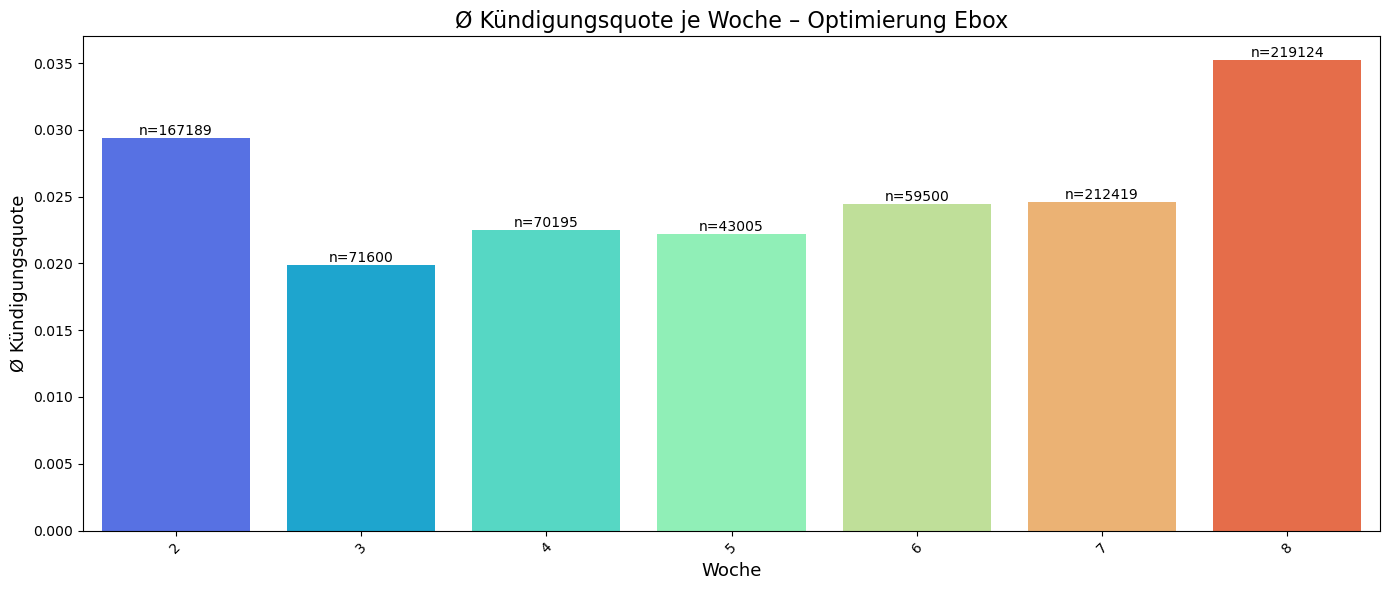



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



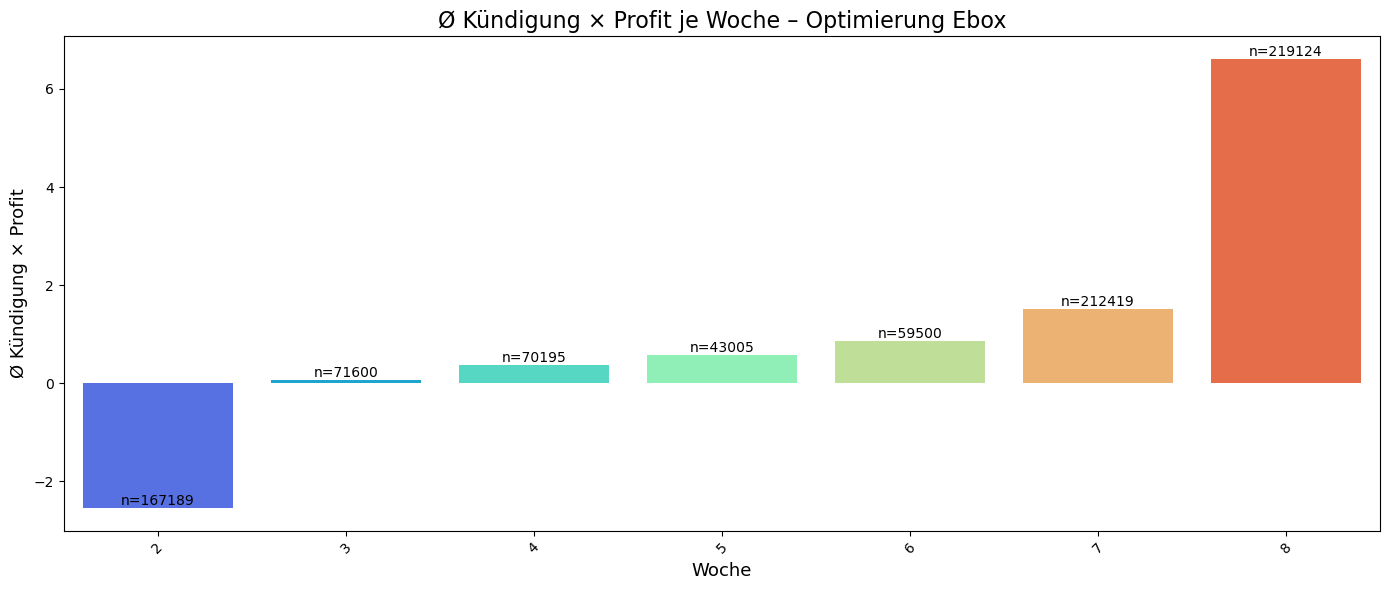

In [217]:
plot_wochenkennzahlen_pro_strategie(df[df['GRUPPE'] == 'Optimierung Ebox'], "Optimierung Ebox")



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



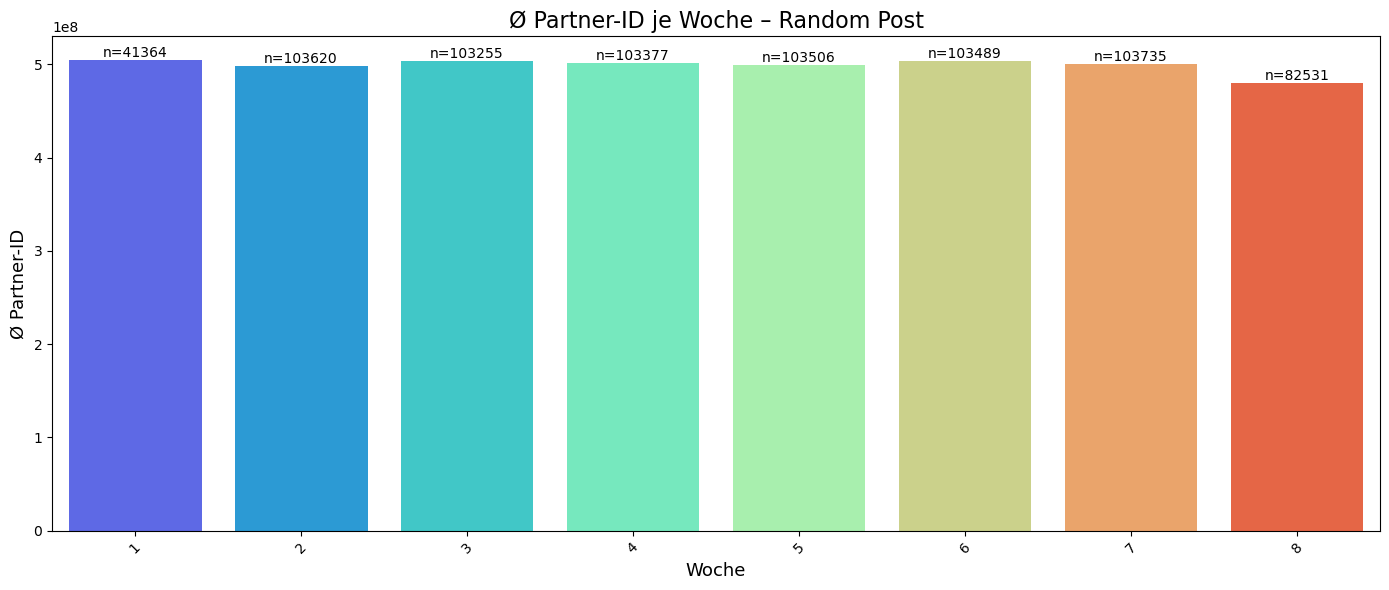



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



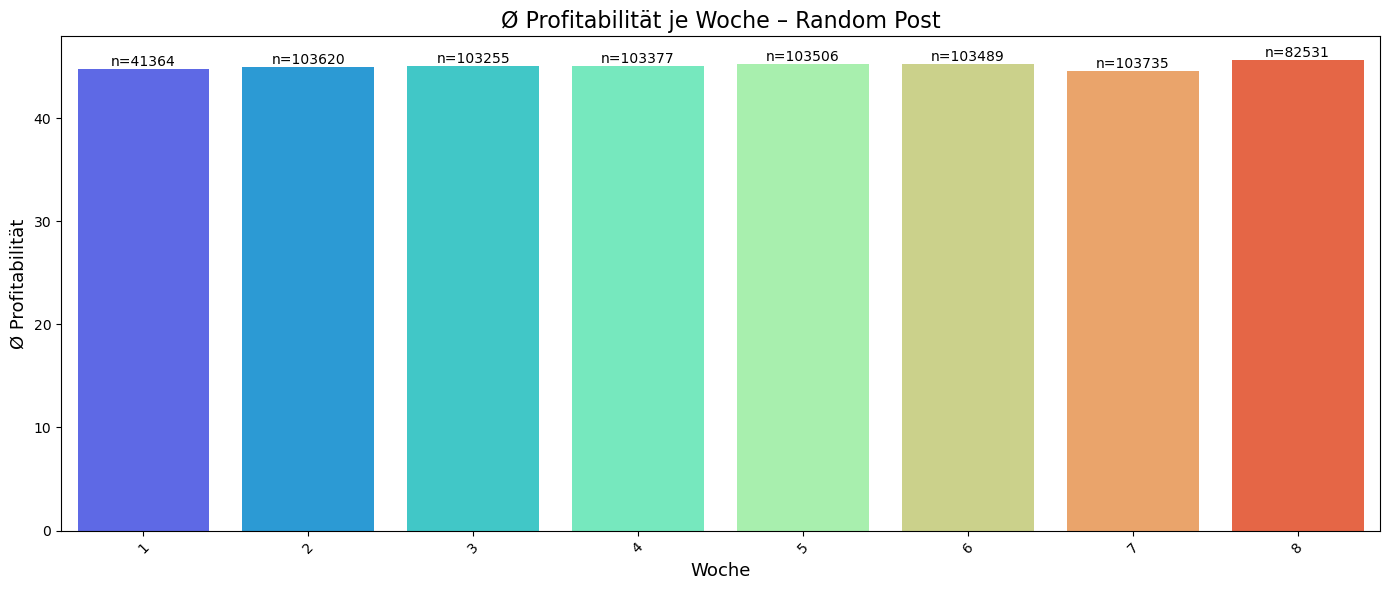



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



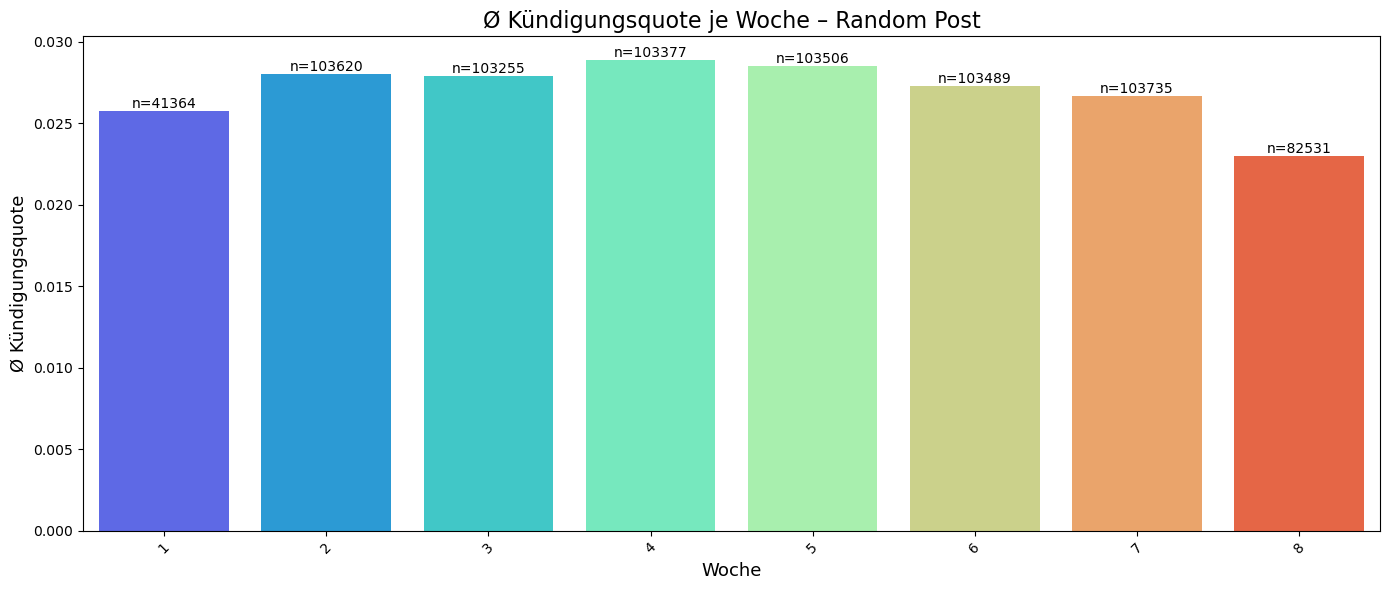



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



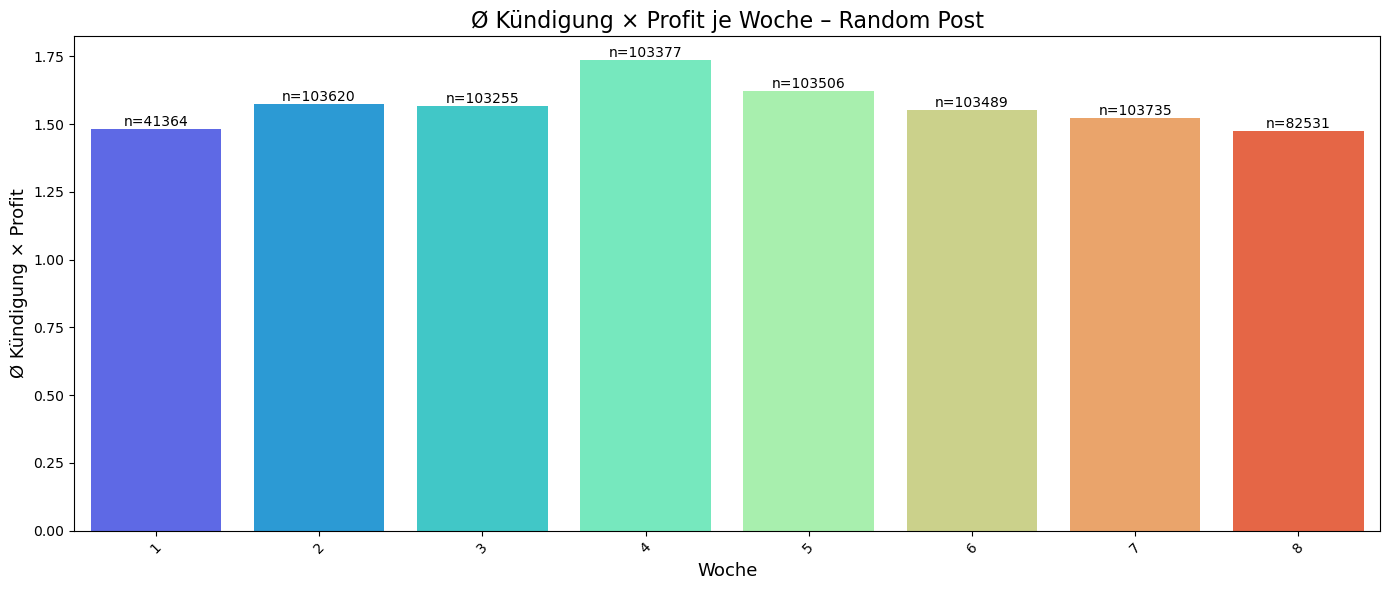

In [218]:
plot_wochenkennzahlen_pro_strategie(df[df['GRUPPE'] == 'Random Post'], "Random Post")



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



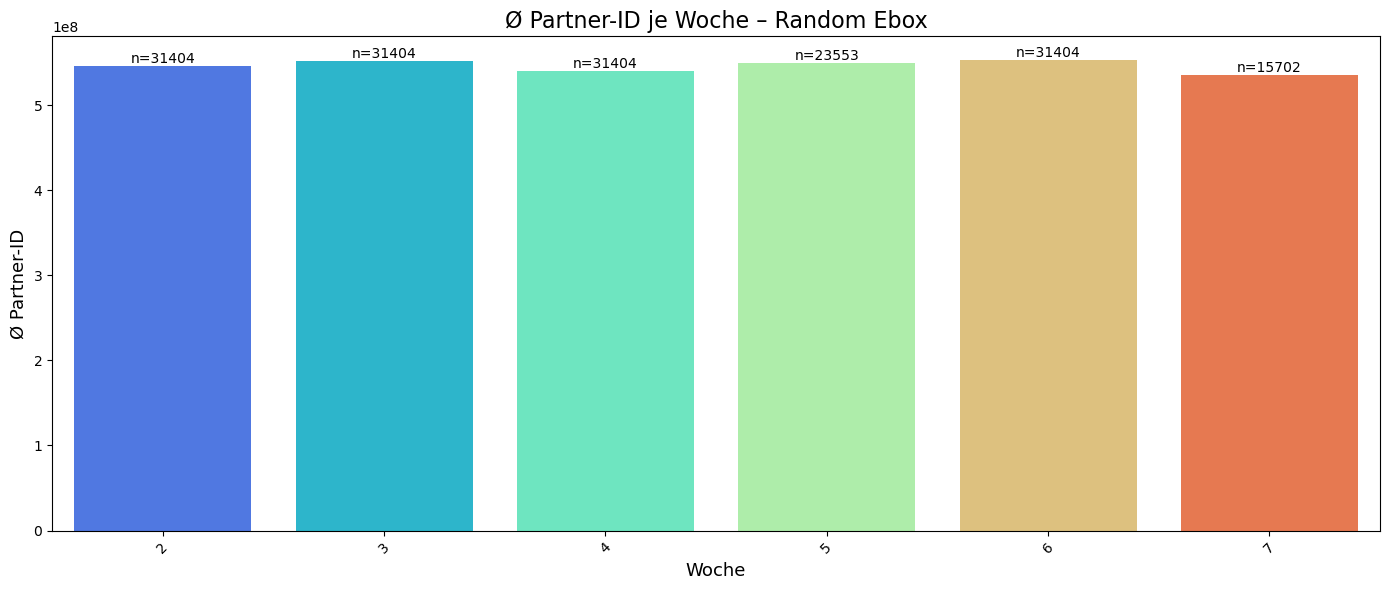



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



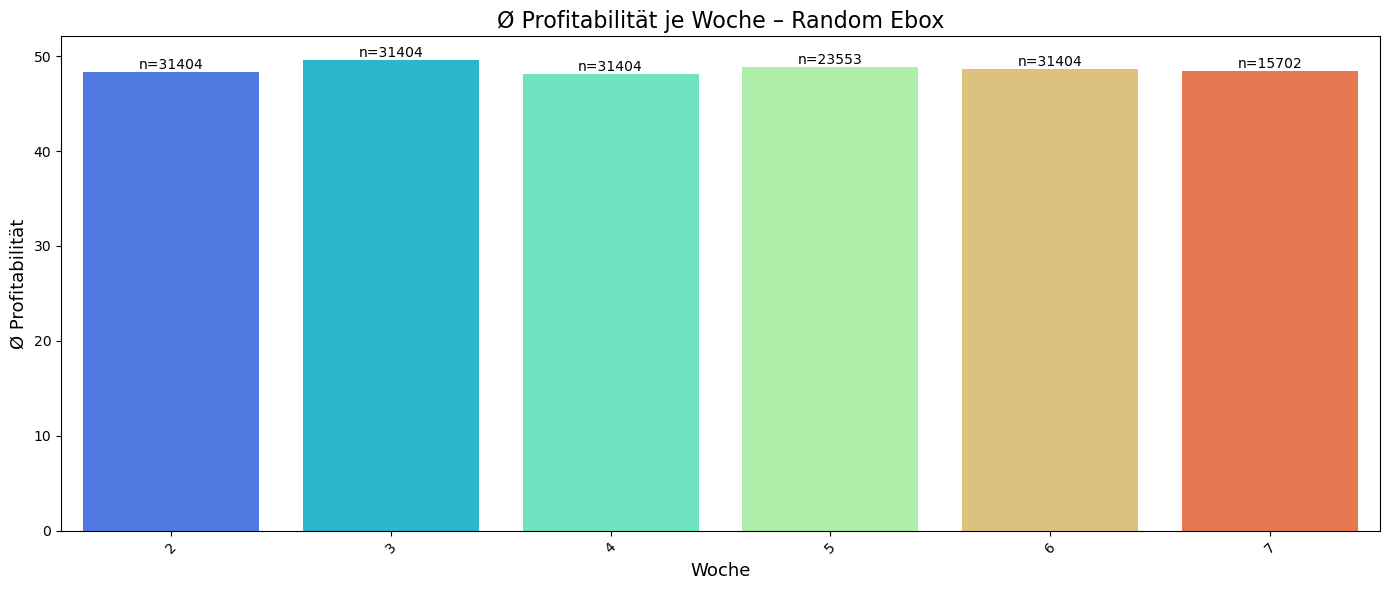



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



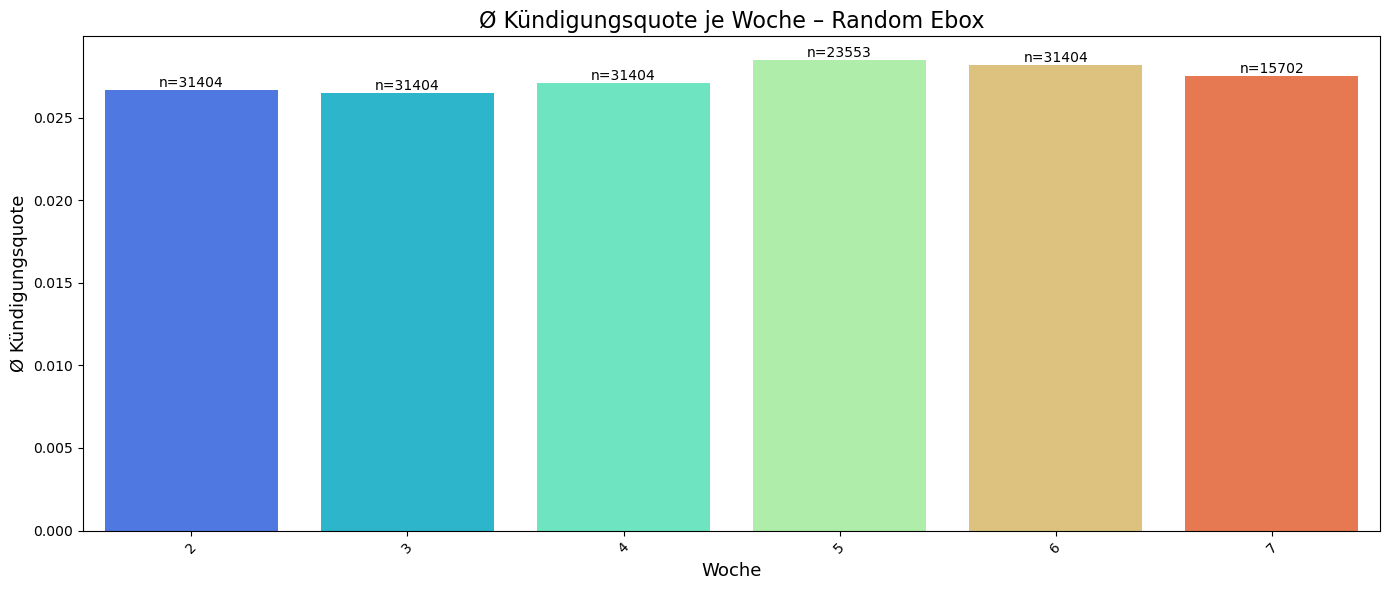



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



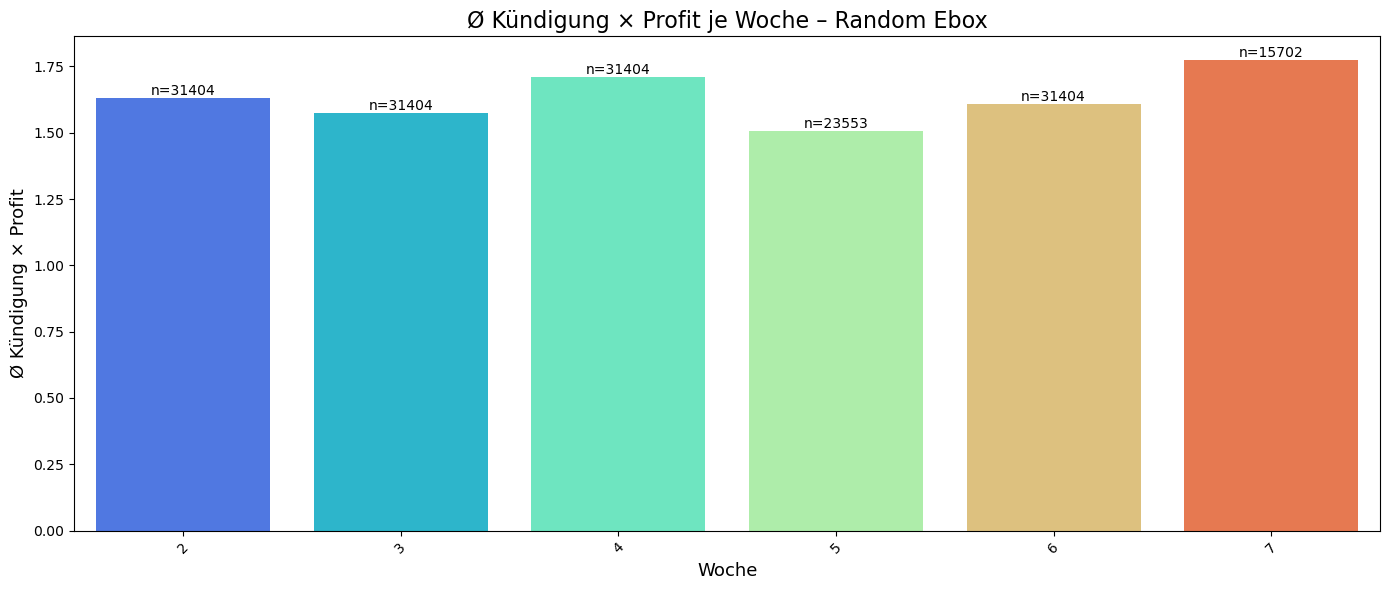

In [219]:
plot_wochenkennzahlen_pro_strategie(df[df['GRUPPE'] == 'Random Ebox'], "Random Ebox")



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



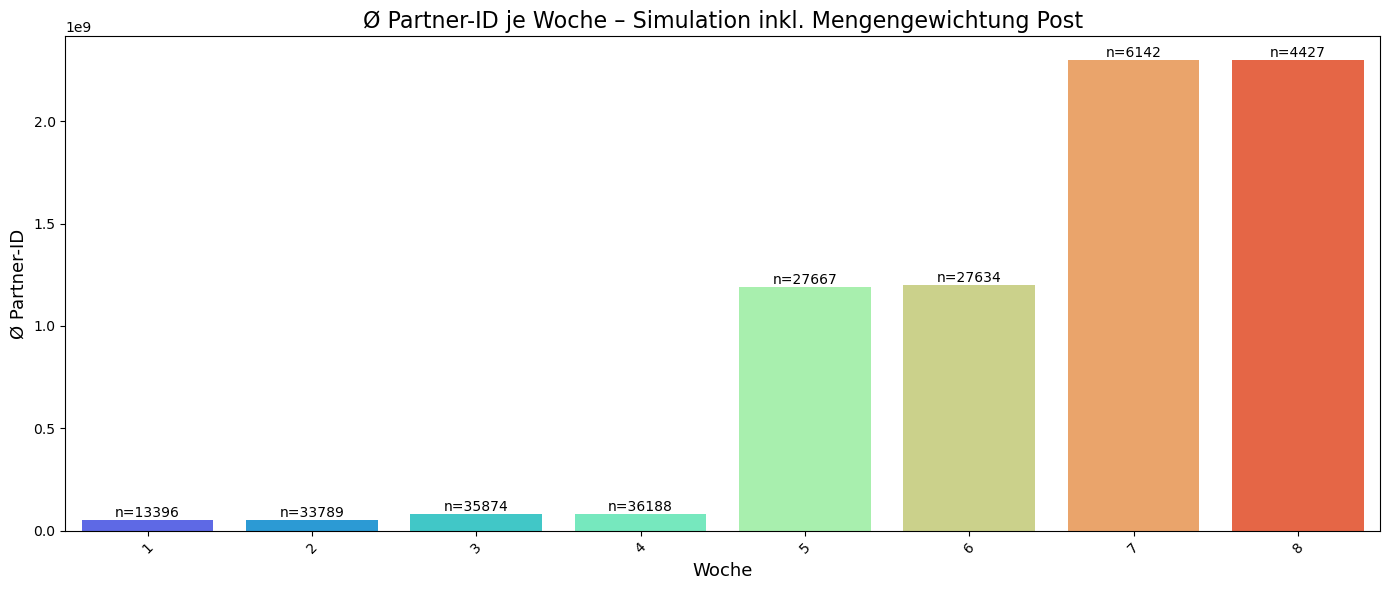



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



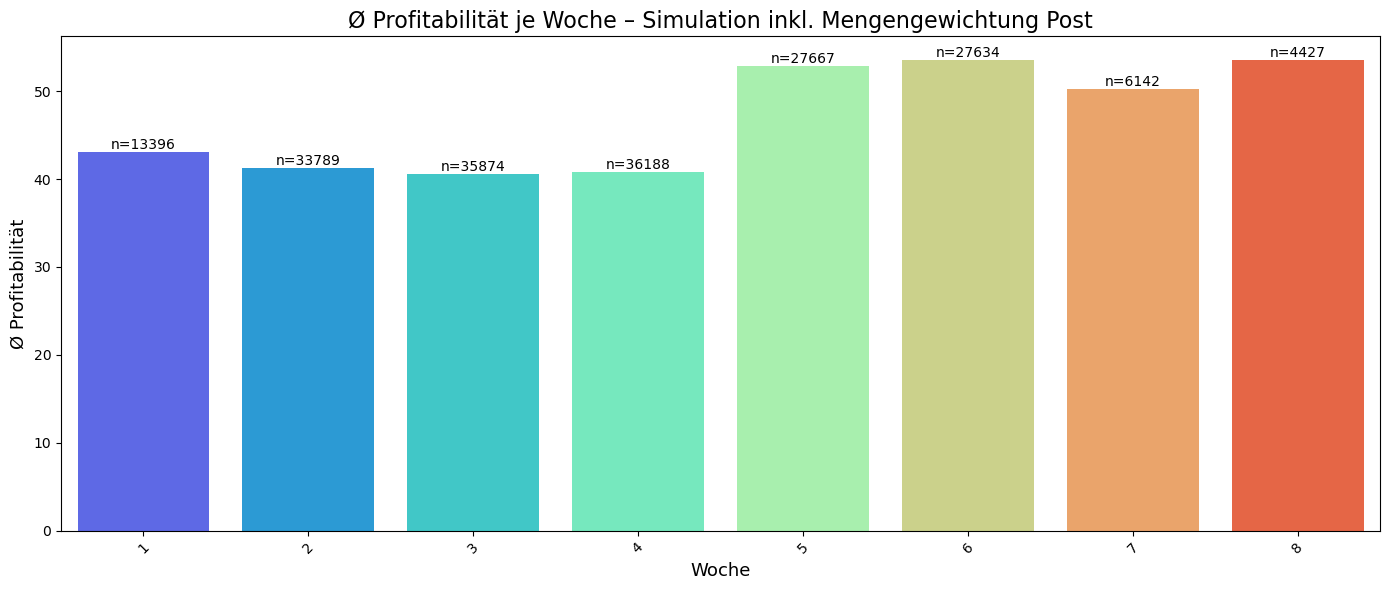



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



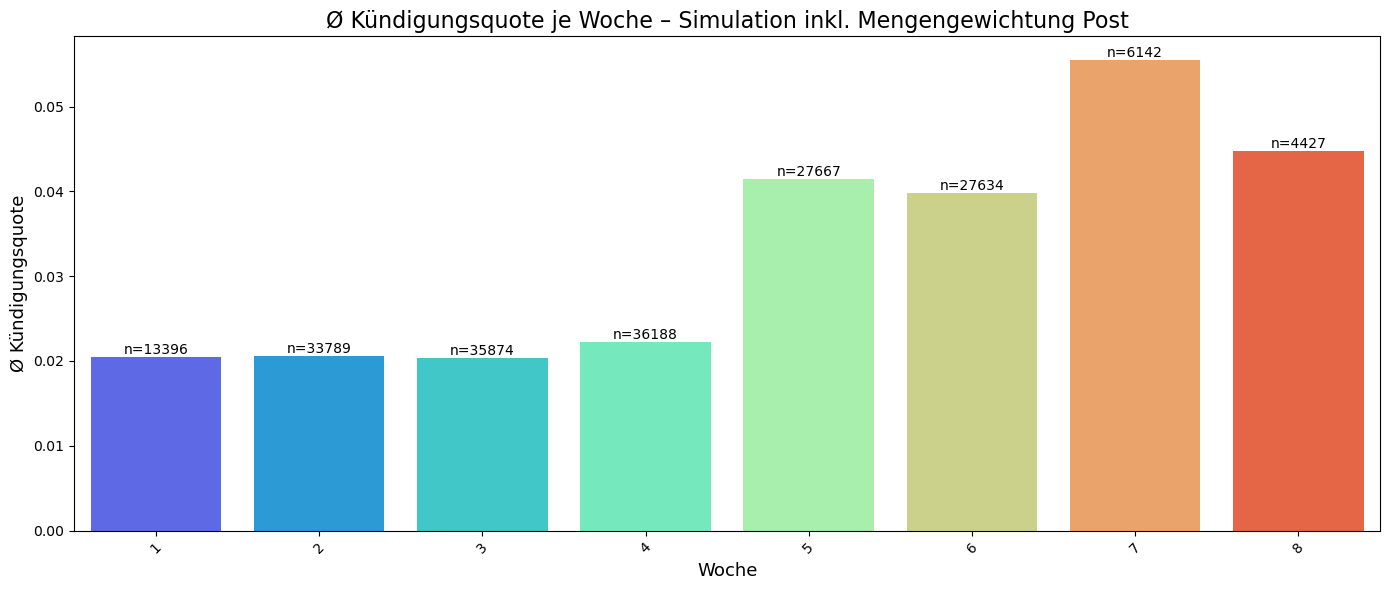



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



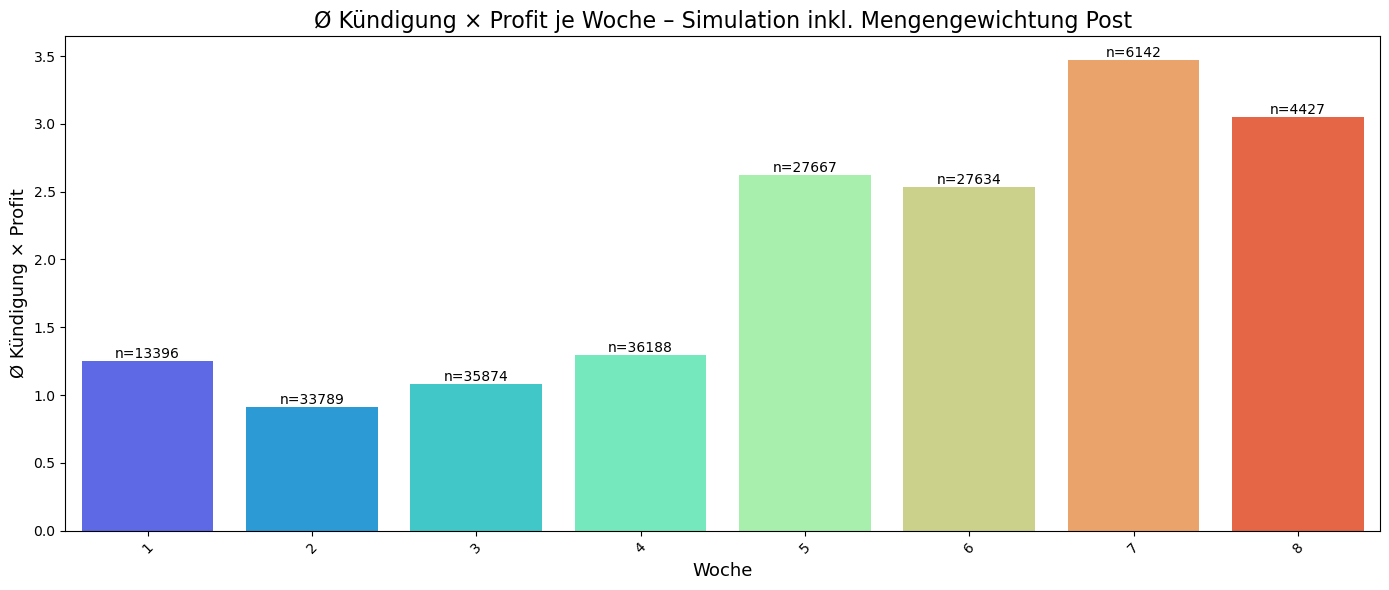

In [220]:
plot_wochenkennzahlen_pro_strategie(df_sim_gewichtung_post, "Simulation inkl. Mengengewichtung Post")



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



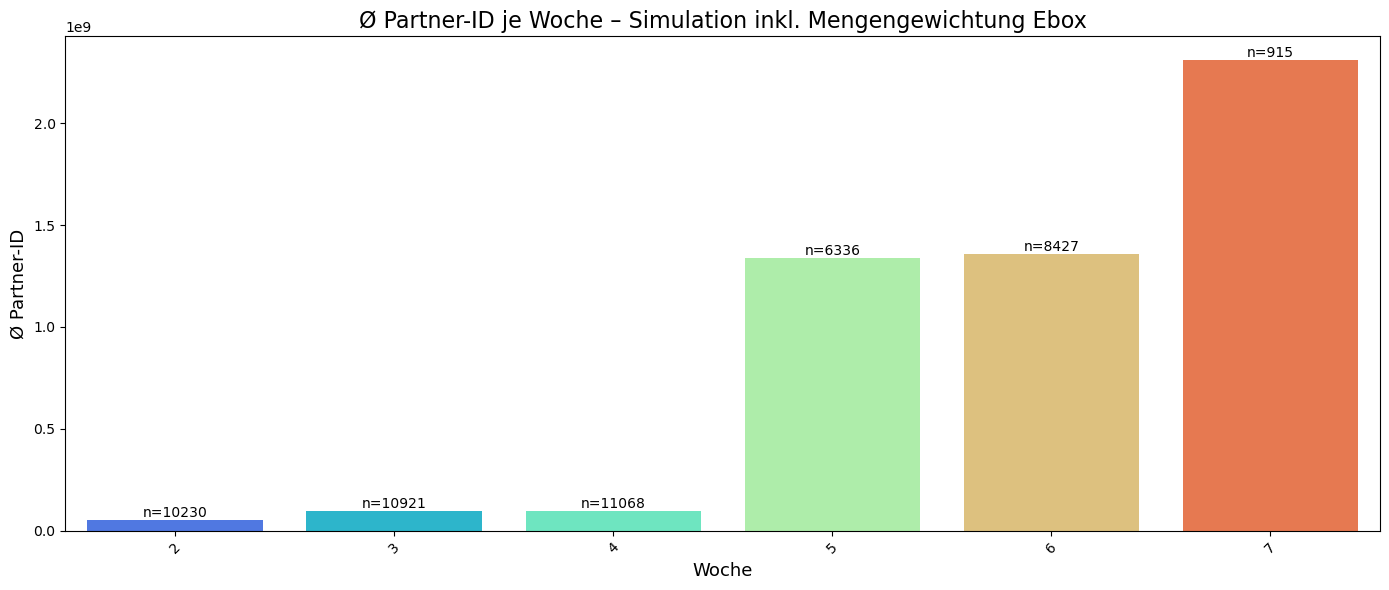



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



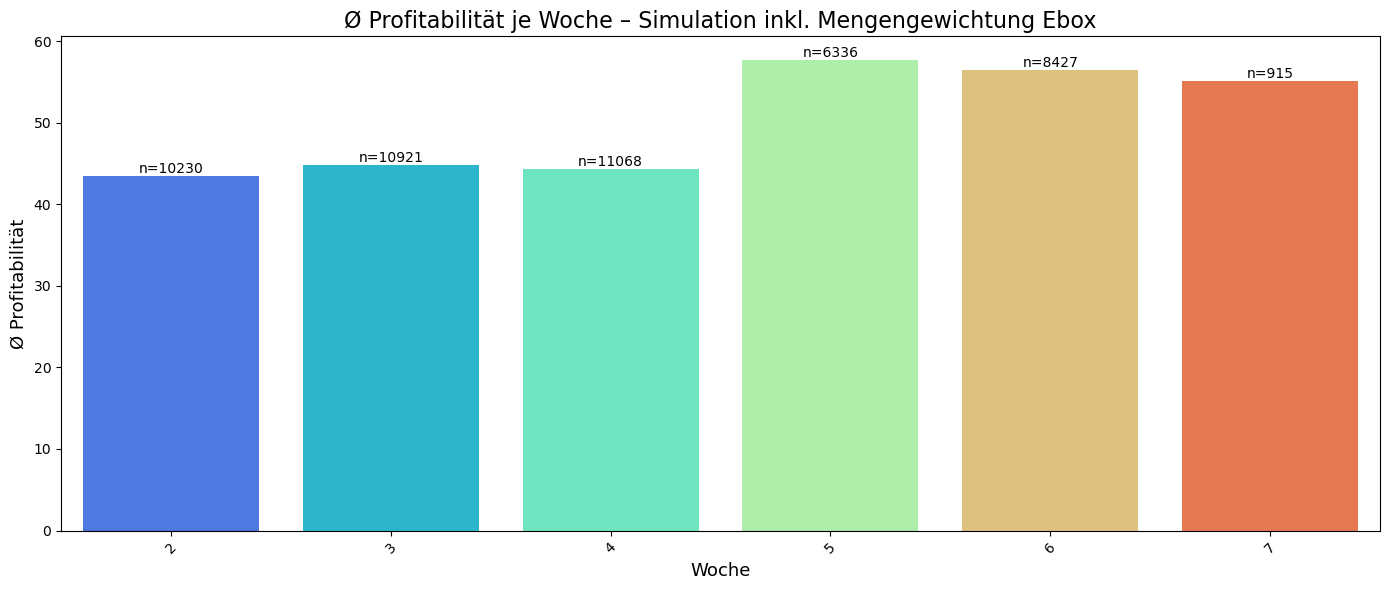



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



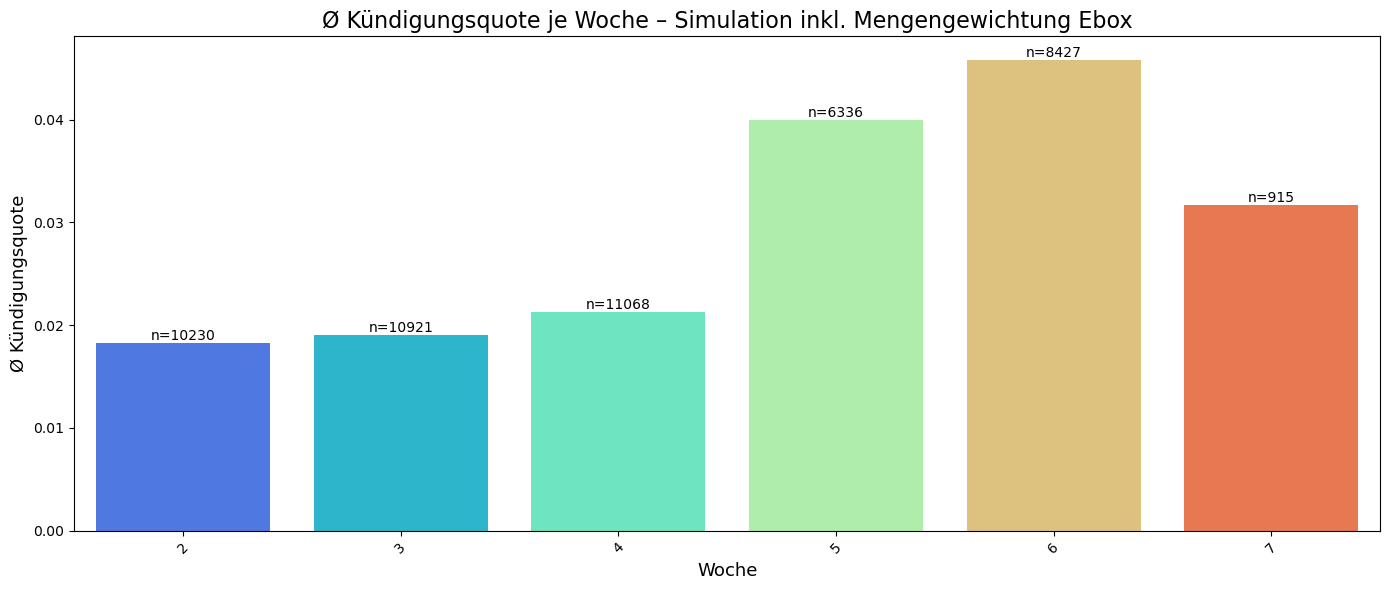



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



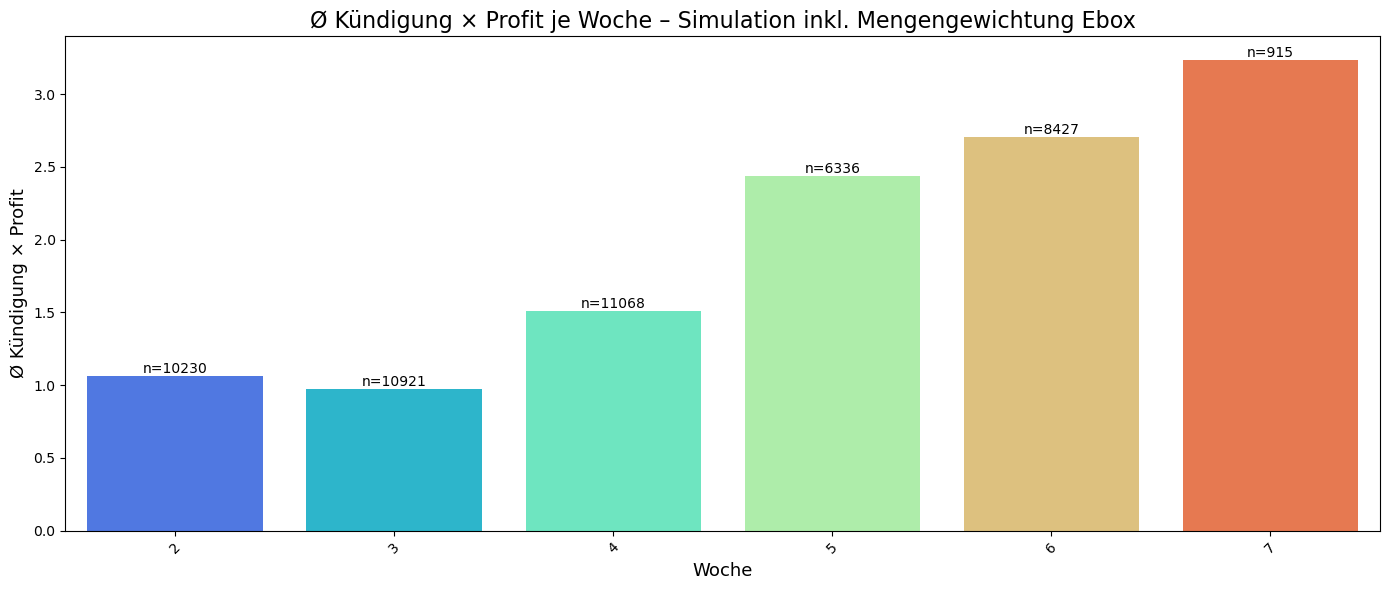

In [221]:
plot_wochenkennzahlen_pro_strategie(df_sim_gewichtung_ebox, "Simulation inkl. Mengengewichtung Ebox")

# Random Post und Ebox Vergleiche

In [222]:
def berechne_mehrwert_zwischen_zwei_gruppen(
    df,
    spalte,
    gruppe1,
    gruppe2,
    gruppenspalte='GRUPPE',
    skaliere_mit_anzahl=True,
    beschreibung=None
):
    df1 = df[df[gruppenspalte] == gruppe1]
    df2 = df[df[gruppenspalte] == gruppe2]
 
    mw1 = df1[spalte].mean()
    mw2 = df2[spalte].mean()
    delta = mw2 - mw1
    mehrwert = delta * len(df1) if skaliere_mit_anzahl else delta
 
    return {
        "Metrik": beschreibung or spalte,
        f"Ø {gruppe1}": round(mw1, 4),
        f"Ø {gruppe2}": round(mw2, 4),
        "Delta Durchschnittstarget": round(delta, 4)
    }

In [223]:
def berechne_randompost_vs_ebox_übersicht(df):
    """
    Gibt eine Vergleichstabelle zwischen Random Post und E-Box für verschiedene Metriken zurück.
    """
    vergleiche = [
        ('KÜNDIGUNG', 'Kündigungsquote'),
        ('KÜNDIGUNG_MAL_PROFIT', 'Kündigung × Profit'),
        ('ve_profit', 'Profit bei Kündigung (nur Kündiger)')
    ]
 
    ergebnisse = []
 
    for spalte, beschreibung in vergleiche:
        if spalte == 've_profit':
            df1 = df[(df['GRUPPE'] == 'Random Post') & (df['KÜNDIGUNG'] == 1)]
            df2 = df[(df['GRUPPE'] == 'Random Ebox') & (df['KÜNDIGUNG'] == 1)]
        else:
            df1 = df[df['GRUPPE'] == 'Random Post']
            df2 = df[df['GRUPPE'] == 'Random Ebox']
 
        result = berechne_mehrwert_zwischen_zwei_gruppen(
            pd.concat([df1, df2]),
            spalte,
            gruppe1='Random Post',
            gruppe2='Random Ebox',
            beschreibung=beschreibung
        )
        ergebnisse.append(result)
 
    return pd.DataFrame(ergebnisse)

In [224]:
vergleich_df = berechne_randompost_vs_ebox_übersicht(df)
vergleich_df

,Metrik,Ø Random Post,Ø Random Ebox,Delta Durchschnittstarget
0,Kündigungsquote,0.0272,0.0273,0.0001
1,Kündigung × Profit,1.5767,1.6267,0.0500
2,Profit bei Kündigung (nur Kündiger),57.9559,59.4945,1.5386
